# PHASE 2: Multi-Factor Analysis of Indian Infrastructure Asset Classes
## MTP2 Dissertation - Building on Phase 1 Volatility & Spillover Results

**Objective:** Explain what drives InvIT, REIT, and Infrastructure Stock returns using macroeconomic factors.

**Methodology:** Incremental factor model comparison (CAPM → Full Model) following Chen, Roll & Ross (1986) and Pham & Phuoc (2020).

**Data:** Weekly frequency, Jul 2020 - Mar 2026 (~290 observations)


In [1]:
# CELL 2: Import all required libraries

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.precision', 4)

print("All libraries imported successfully")


All libraries imported successfully


In [2]:
# CELL 3: Configuration - same tickers and dates as Phase 1

START = '2020-07-27'
END = '2026-03-01'

# India tickers (same as Phase 1)
INDIA_INVITS = ['IRBINVIT.NS', 'INDIGRID.NS', 'PGINVIT.NS']
INDIA_REITS = ['EMBASSY.NS', 'MINDSPACE.NS', 'BIRET.NS']
INDIA_STOCKS = ['IRB.NS', 'LT.NS', 'ADANIPORTS.NS', 'NTPC.NS', 'POWERGRID.NS']

# Market index
NIFTY50 = '^NSEI'

# Macro factor tickers (from Yahoo Finance)
INR_USD = 'INR=X'        # USD/INR exchange rate
BRENT_OIL = 'BZ=F'       # Brent crude futures

# India 10Y bond yield - we'll try multiple tickers
INDIA_10Y_TICKERS = ['IN10Y.NS', 'ININ10YBF.NS']  # May or may not work on Yahoo

ALL_INDIA_TICKERS = INDIA_INVITS + INDIA_REITS + INDIA_STOCKS

print(f"Configuration loaded:")
print(f"  Indian tickers: {len(ALL_INDIA_TICKERS)}")
print(f"  Period: {START} to {END}")
print(f"  Frequency: Weekly")


Configuration loaded:
  Indian tickers: 11
  Period: 2020-07-27 to 2026-03-01
  Frequency: Weekly


In [3]:
# CELL 4: Download price data for Indian tickers

print("Downloading Indian ticker prices...")
prices = pd.DataFrame()

for ticker in ALL_INDIA_TICKERS:
    try:
        data = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
        if not data.empty:
            prices[ticker] = data['Close']
            print(f"  {ticker}: {len(data)} days")
        else:
            print(f"  {ticker}: NO DATA")
    except Exception as e:
        print(f"  {ticker}: ERROR - {e}")

print(f"\nTotal price data: {prices.shape[0]} days x {prices.shape[1]} tickers")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")


  IRBINVIT.NS: 1386 days
  INDIGRID.NS: 1386 days
  PGINVIT.NS: 1188 days
  EMBASSY.NS: 1387 days
  MINDSPACE.NS: 1378 days
  BIRET.NS: 1245 days
  IRB.NS: 1388 days
  LT.NS: 1388 days
  ADANIPORTS.NS: 1388 days
  NTPC.NS: 1388 days
  POWERGRID.NS: 1388 days

Total price data: 1386 days x 11 tickers
Date range: 2020-07-27 to 2026-02-27


In [4]:
# CELL 5: Download macro factor data

print("Downloading macro factor data...")

# Nifty 50
nifty_data = yf.download(NIFTY50, start=START, end=END, progress=False, auto_adjust=True)
print(f"  Nifty 50: {len(nifty_data)} days")

# INR/USD exchange rate
inr_data = yf.download(INR_USD, start=START, end=END, progress=False, auto_adjust=True)
print(f"  INR/USD: {len(inr_data)} days")

# Brent crude oil
oil_data = yf.download(BRENT_OIL, start=START, end=END, progress=False, auto_adjust=True)
print(f"  Brent Oil: {len(oil_data)} days")

# India 10Y bond yield - load from downloaded CSV (Investing.com)
india_10y_raw = pd.read_csv('C:\\Users\\HP\\Desktop\\mtp2\\phase 2 test code\\India 10-Year Bond Yield Historical Data (1).csv')
india_10y_raw['Date'] = pd.to_datetime(india_10y_raw['Date'], format='%d-%m-%Y')
india_10y_raw = india_10y_raw.sort_values('Date').set_index('Date')
india_10y_raw['Price'] = pd.to_numeric(india_10y_raw['Price'], errors='coerce')
india_10y = india_10y_raw[['Price']].rename(columns={'Price': 'Close'})
india_10y = india_10y.dropna()
print(f"  India 10Y Yield (CSV): {len(india_10y)} days")
print(f"    Range: {india_10y.index[0].date()} to {india_10y.index[-1].date()}")
print(f"    Yield range: {india_10y['Close'].min():.3f}% to {india_10y['Close'].max():.3f}%")

  Nifty 50: 1386 days
  INR/USD: 1455 days
  Brent Oil: 1408 days
  India 10Y Yield (CSV): 1369 days
    Range: 2020-07-27 to 2026-02-27
    Yield range: 5.825% to 7.617%


In [5]:
# CELL 4b (NEW): ADF unit-root tests on India 10Y yield (level and first difference)
#
# Yield_Level_dm is used as a regressor in Phase 2 Cells 41 and 43 (and
# indirectly in Phase 3 via the lagged panel). Yields are often near-unit-root
# in Indian data. If the level is non-stationary but the regressand (weekly
# returns) is stationary, the yield-level coefficients could be artefacts of
# common trends rather than a genuine competing-asset effect.
#
# This cell runs ADF on the level (constant only, and constant+trend) and
# on the first difference (constant only), and reports the decision.

from statsmodels.tsa.stattools import adfuller

yield_level  = india_10y['Close'].dropna()
yield_change = yield_level.diff().dropna()

def _adf_row(series, regression, label):
    stat, pval, usedlag, nobs, crit, _ = adfuller(series, regression=regression,
                                                   autolag='AIC')
    return {
        'Test'      : label,
        'ADF_stat'  : round(float(stat),  4),
        'p_value'   : round(float(pval),  4),
        'lags_used' : int(usedlag),
        'n_obs'     : int(nobs),
        '1%_crit'   : round(float(crit['1%']),  3),
        '5%_crit'   : round(float(crit['5%']),  3),
        '10%_crit'  : round(float(crit['10%']), 3),
        'Stationary@5%': 'YES' if pval < 0.05 else 'NO',
    }

adf_table = pd.DataFrame([
    _adf_row(yield_level,  'c',  'Level,  const only'),
    _adf_row(yield_level,  'ct', 'Level,  const + trend'),
    _adf_row(yield_change, 'c',  'Δyield, const only'),
]).set_index('Test')

print("=" * 80)
print("ADF unit-root tests — India 10Y Bond Yield")
print("=" * 80)
print(adf_table.to_string())

level_stationary  = adf_table.loc['Level,  const only', 'p_value'] < 0.05
change_stationary = adf_table.loc['Δyield, const only', 'p_value'] < 0.05

print()
print("Interpretation:")
if level_stationary:
    print("  ✓ Yield level is stationary at 5%. Regressing weekly returns on")
    print("    Yield_Level_dm is not in spurious-regression territory.")
    print("    Competing-asset finding (Phase 2 Cell 41) stands on solid ground.")
elif change_stationary and not level_stationary:
    print("  ⚠ Yield level appears to have a unit root but Δyield is stationary.")
    print("    Yield_Level_dm is I(1). Weekly returns are I(0). The level-on-returns")
    print("    regression is technically in spurious-regression territory over long")
    print("    horizons, though the 5.7-year sample here is short enough that the")
    print("    distortion is typically small. Dissertation options:")
    print("      (a) keep Yield_Level_dm with an explicit ADF caveat in the text;")
    print("      (b) replace with residual from AR(1) of yield level;")
    print("      (c) switch to yield-change-only specifications.")
    print("    Recommended: (a) — the competing-asset result is economically")
    print("    interpretable and the sample length limits the spurious-regression risk.")
else:
    print("  ⚠ Neither level nor first difference rejects the unit-root null.")
    print("    Investigate: may need higher-order differencing or a different")
    print("    specification entirely.")

ADF unit-root tests — India 10Y Bond Yield
                       ADF_stat  p_value  lags_used  n_obs  1%_crit  5%_crit  10%_crit Stationary@5%
Test                                                                                                
Level,  const only      -1.8708   0.3459          2   1366   -3.435   -2.864    -2.568            NO
Level,  const + trend   -1.4497   0.8457          2   1366   -3.965   -3.414    -3.129            NO
Δyield, const only     -29.0560   0.0000          1   1366   -3.435   -2.864    -2.568           YES

Interpretation:
  ⚠ Yield level appears to have a unit root but Δyield is stationary.
    Yield_Level_dm is I(1). Weekly returns are I(0). The level-on-returns
    regression is technically in spurious-regression territory over long
    horizons, though the 5.7-year sample here is short enough that the
    distortion is typically small. Dissertation options:
      (a) keep Yield_Level_dm with an explicit ADF caveat in the text;
      (b) replace w

In [6]:
# CELL 6: Calculate daily log returns and create category portfolios
# (Same approach as Phase 1 - equal-weighted portfolios)

# Daily log returns
returns = np.log(prices / prices.shift(1)).dropna()
print(f"Daily returns: {returns.shape[0]} days x {returns.shape[1]} tickers")

# Equal-weighted category portfolios (same as Phase 1)
portfolio_invit = returns[INDIA_INVITS].mean(axis=1)
portfolio_reit = returns[INDIA_REITS].mean(axis=1)
portfolio_stock = returns[INDIA_STOCKS].mean(axis=1)

# Combine into one DataFrame
daily_portfolios = pd.DataFrame({
    'India_InvIT': portfolio_invit,
    'India_REIT': portfolio_reit,
    'India_Stock': portfolio_stock
})

print(f"\nDaily category portfolios created:")
print(f"  Shape: {daily_portfolios.shape}")
print(f"  Date range: {daily_portfolios.index[0].date()} to {daily_portfolios.index[-1].date()}")
print(f"\nDaily return statistics (annualized):")
print((daily_portfolios.mean() * 252 * 100).round(2).to_string())


Daily returns: 1183 days x 11 tickers

Daily category portfolios created:
  Shape: (1183, 3)
  Date range: 2021-05-17 to 2026-02-27

Daily return statistics (annualized):
India_InvIT     9.22
India_REIT     14.06
India_Stock    24.73


In [7]:
# CELL 7: Create daily factor returns

# Helper to extract close prices safely (handles multi-level columns from yfinance)
def get_close(data):
    if isinstance(data.columns, pd.MultiIndex):
        return data['Close'].iloc[:, 0]
    else:
        return data['Close']

# Market factor: Nifty 50 log return
nifty_close = get_close(nifty_data)
nifty_ret = np.log(nifty_close / nifty_close.shift(1)).dropna()
nifty_ret.name = 'Nifty50'

# Exchange rate factor: log change in INR/USD
inr_close = get_close(inr_data)
inr_ret = np.log(inr_close / inr_close.shift(1)).dropna()
inr_ret.name = 'INR_USD'

# Oil factor: Brent crude log return
oil_close = get_close(oil_data)
oil_ret = np.log(oil_close / oil_close.shift(1)).dropna()
oil_ret.name = 'Oil'

# Interest rate factor: daily change in India 10Y yield (in percentage points)
yield_change = india_10y['Close'].diff().dropna()
yield_change.name = 'Yield_10Y'
print(f"India 10Y yield change: {len(yield_change)} days")
print(f"  Mean daily change: {yield_change.mean():.4f} pp")
print(f"  Std daily change: {yield_change.std():.4f} pp")

# Combine daily factors
daily_factors = pd.DataFrame({
    'Nifty50': nifty_ret,
    'INR_USD': inr_ret,
    'Oil': oil_ret,
    'Yield_10Y': yield_change
})

# Drop any rows with NaN
daily_factors = daily_factors.dropna()

print(f"\nDaily factors created: {daily_factors.shape}")
print(f"Columns: {list(daily_factors.columns)}")
print(f"Date range: {daily_factors.index[0].date()} to {daily_factors.index[-1].date()}")

India 10Y yield change: 1368 days
  Mean daily change: 0.0006 pp
  Std daily change: 0.0318 pp

Daily factors created: (1314, 4)
Columns: ['Nifty50', 'INR_USD', 'Oil', 'Yield_10Y']
Date range: 2020-07-28 to 2026-02-27


In [8]:
# CELL 8: Aggregate daily data to weekly frequency
# For returns: sum daily log returns within each week
# For yield changes: sum daily changes within each week

# Weekly portfolio returns (sum of daily log returns = log of weekly price ratio)
weekly_portfolios = daily_portfolios.resample('W-FRI').sum()

# Weekly factor returns (sum of daily log returns)
weekly_factors = daily_factors[['Nifty50', 'INR_USD', 'Oil']].resample('W-FRI').sum()

# Weekly yield change (sum of daily changes)
if 'Yield_10Y' in daily_factors.columns:
    weekly_factors['Yield_10Y'] = daily_factors['Yield_10Y'].resample('W-FRI').sum()

# Drop weeks with missing data
weekly_portfolios = weekly_portfolios.dropna()
weekly_factors = weekly_factors.dropna()

# Align dates
common_dates = weekly_portfolios.index.intersection(weekly_factors.index)
weekly_portfolios = weekly_portfolios.loc[common_dates]
weekly_factors = weekly_factors.loc[common_dates]

print(f"Weekly data created:")
print(f"  Portfolios: {weekly_portfolios.shape[0]} weeks x {weekly_portfolios.shape[1]} categories")
print(f"  Factors: {weekly_factors.shape[0]} weeks x {weekly_factors.shape[1]} factors")
print(f"  Date range: {common_dates[0].date()} to {common_dates[-1].date()}")
print(f"\nFactor columns: {list(weekly_factors.columns)}")


Weekly data created:
  Portfolios: 250 weeks x 3 categories
  Factors: 250 weeks x 4 factors
  Date range: 2021-05-21 to 2026-02-27

Factor columns: ['Nifty50', 'INR_USD', 'Oil', 'Yield_10Y']


In [9]:
# CELL 9: Descriptive statistics of weekly data

print("=" * 80)
print("WEEKLY PORTFOLIO RETURN STATISTICS")
print("=" * 80)

port_stats = weekly_portfolios.describe().T
port_stats['annualized_mean'] = port_stats['mean'] * 52
port_stats['annualized_std'] = port_stats['std'] * np.sqrt(52)
port_stats['sharpe'] = port_stats['annualized_mean'] / port_stats['annualized_std']
print(port_stats[['mean', 'std', 'annualized_mean', 'annualized_std', 'sharpe']].round(4))

print("\n" + "=" * 80)
print("WEEKLY FACTOR STATISTICS")
print("=" * 80)
factor_stats = weekly_factors.describe().T
print(factor_stats.round(6))

print("\n" + "=" * 80)
print("CORRELATION MATRIX: Portfolios vs Factors")
print("=" * 80)
combined = pd.concat([weekly_portfolios, weekly_factors], axis=1)
corr = combined.corr().round(3)
print(corr)


WEEKLY PORTFOLIO RETURN STATISTICS
               mean     std  annualized_mean  annualized_std  sharpe
India_InvIT  0.0017  0.0158           0.0900          0.1142  0.7883
India_REIT   0.0026  0.0148           0.1373          0.1071  1.2821
India_Stock  0.0046  0.0312           0.2415          0.2247  1.0748

WEEKLY FACTOR STATISTICS
           count    mean     std     min     25%     50%     75%     max
Nifty50    250.0  0.0016  0.0175 -0.0577 -0.0089  0.0033  0.0137  0.0438
INR_USD    250.0  0.0009  0.0054 -0.0251 -0.0016  0.0005  0.0036  0.0169
Oil        250.0  0.0012  0.0438 -0.1475 -0.0223  0.0031  0.0279  0.1487
Yield_10Y  250.0  0.0027  0.0580 -0.1810 -0.0250  0.0025  0.0350  0.3120

CORRELATION MATRIX: Portfolios vs Factors
             India_InvIT  India_REIT  India_Stock  Nifty50  INR_USD    Oil  Yield_10Y
India_InvIT        1.000       0.129        0.046    0.066   -0.045 -0.010     -0.075
India_REIT         0.129       1.000        0.339    0.191   -0.173 -0.001      0.0

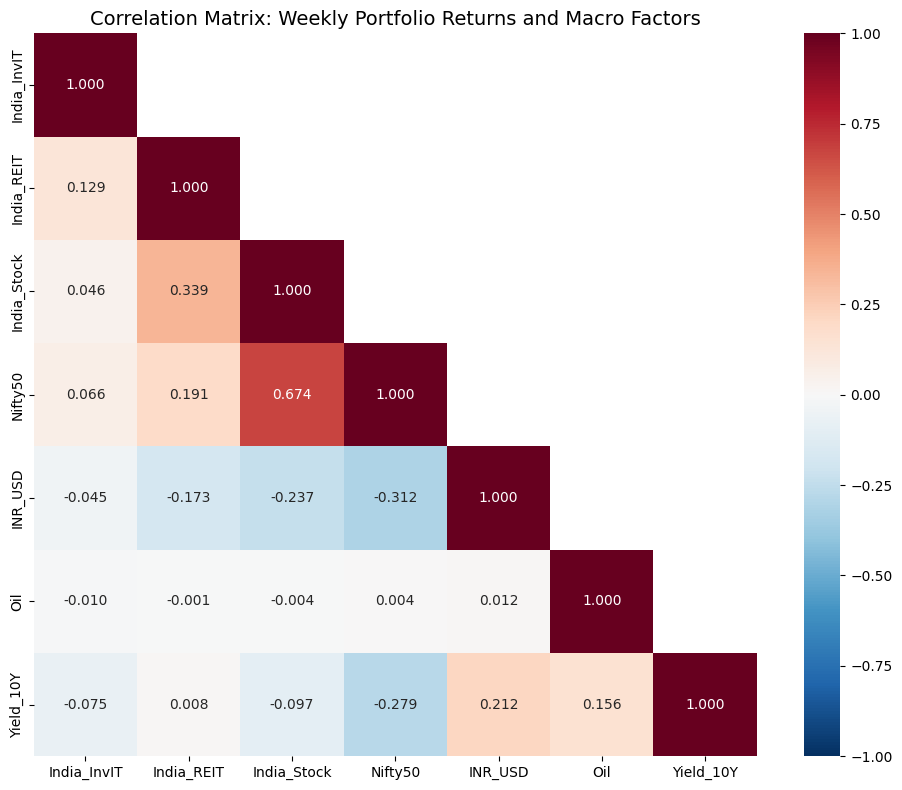

In [10]:
# CELL 10: Correlation heatmap - Portfolios and Factors

fig, ax = plt.subplots(figsize=(10, 8))
combined = pd.concat([weekly_portfolios, weekly_factors], axis=1)
corr = combined.corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix: Weekly Portfolio Returns and Macro Factors', fontsize=14)
plt.tight_layout()
plt.show()


In [11]:
# CELL 11: Helper function for running and summarizing regressions

def run_regression(y, X, y_name, model_name):
    """
    Run OLS regression with HAC (Newey-West) standard errors.
    Returns a dictionary with key results.
    """
    X_const = add_constant(X)
    model = OLS(y, X_const).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
    
    result = {
        'y_name': y_name,
        'model_name': model_name,
        'nobs': int(model.nobs),
        'r_squared': model.rsquared,
        'adj_r_squared': model.rsquared_adj,
        'aic': model.aic,
        'bic': model.bic,
        'f_stat': model.fvalue,
        'f_pvalue': model.f_pvalue,
        'durbin_watson': durbin_watson(model.resid),
        'params': model.params,
        'tvalues': model.tvalues,
        'pvalues': model.pvalues,
        'bse': model.bse,
        'model_obj': model
    }
    return result

def print_regression_results(result):
    """Pretty print regression results."""
    print(f"\n{'='*70}")
    print(f"Dependent Variable: {result['y_name']}  |  Model: {result['model_name']}")
    print(f"{'='*70}")
    print(f"Observations: {result['nobs']}  |  R-squared: {result['r_squared']:.4f}  |  Adj R-squared: {result['adj_r_squared']:.4f}")
    print(f"AIC: {result['aic']:.2f}  |  BIC: {result['bic']:.2f}  |  DW: {result['durbin_watson']:.3f}")
    print(f"F-stat: {result['f_stat']:.3f}  (p={result['f_pvalue']:.4f})")
    print(f"{'-'*70}")
    print(f"{'Variable':<15} {'Coeff':>10} {'Std Err':>10} {'t-stat':>10} {'p-value':>10} {'Sig':>5}")
    print(f"{'-'*70}")
    
    for var in result['params'].index:
        coef = result['params'][var]
        se = result['bse'][var]
        t = result['tvalues'][var]
        p = result['pvalues'][var]
        sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
        print(f"{var:<15} {coef:>10.6f} {se:>10.6f} {t:>10.3f} {p:>10.4f} {sig:>5}")
    print(f"{'='*70}")

print("Regression helper functions defined")


Regression helper functions defined


In [12]:
# CELL 12: MODEL 1 - CAPM (Nifty 50 only)
# R_i = alpha + beta * R_nifty + epsilon

print("=" * 80)
print("MODEL 1: CAPM (Market Factor Only)")
print("=" * 80)

categories = ['India_InvIT', 'India_REIT', 'India_Stock']
model1_results = {}

for cat in categories:
    y = weekly_portfolios[cat]
    X = weekly_factors[['Nifty50']]
    result = run_regression(y, X, cat, 'CAPM')
    model1_results[cat] = result
    print_regression_results(result)


MODEL 1: CAPM (Market Factor Only)

Dependent Variable: India_InvIT  |  Model: CAPM
Observations: 250  |  R-squared: 0.0044  |  Adj R-squared: 0.0003
AIC: -1361.44  |  BIC: -1354.39  |  DW: 1.896
F-stat: 0.801  (p=0.3717)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.001635   0.001007      1.624     0.1044      
Nifty50           0.059644   0.066647      0.895     0.3708      

Dependent Variable: India_REIT  |  Model: CAPM
Observations: 250  |  R-squared: 0.0364  |  Adj R-squared: 0.0325
AIC: -1401.79  |  BIC: -1394.75  |  DW: 2.118
F-stat: 8.554  (p=0.0038)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.002381   0.000853      2

In [13]:
# CELL 13: MODEL 2 - CAPM + Interest Rate (if available)
# R_i = alpha + beta1 * R_nifty + beta2 * Delta_Yield_10Y + epsilon

print("=" * 80)
print("MODEL 2: CAPM + Interest Rate")
print("=" * 80)

model2_results = {}

if 'Yield_10Y' in weekly_factors.columns:
    for cat in categories:
        y = weekly_portfolios[cat]
        X = weekly_factors[['Nifty50', 'Yield_10Y']]
        result = run_regression(y, X, cat, 'CAPM + Interest Rate')
        model2_results[cat] = result
        print_regression_results(result)
else:
    print("India 10Y yield data not available.")
    print("Skipping to Model 2b: CAPM + Exchange Rate")
    print("\n>>> To include interest rates, upload India 10Y yield data <<<")
    print(">>> Then re-run from Cell 7 <<<")
    
    # Model 2b: CAPM + Exchange Rate (as fallback)
    for cat in categories:
        y = weekly_portfolios[cat]
        X = weekly_factors[['Nifty50', 'INR_USD']]
        result = run_regression(y, X, cat, 'CAPM + Exchange Rate')
        model2_results[cat] = result
        print_regression_results(result)


MODEL 2: CAPM + Interest Rate

Dependent Variable: India_InvIT  |  Model: CAPM + Interest Rate
Observations: 250  |  R-squared: 0.0078  |  Adj R-squared: -0.0002
AIC: -1360.30  |  BIC: -1349.74  |  DW: 1.875
F-stat: 2.529  (p=0.0818)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.001705   0.000964      1.770     0.0767     *
Nifty50           0.044196   0.078782      0.561     0.5748      
Yield_10Y        -0.016701   0.017877     -0.934     0.3502      

Dependent Variable: India_REIT  |  Model: CAPM + Interest Rate
Observations: 250  |  R-squared: 0.0405  |  Adj R-squared: 0.0327
AIC: -1400.86  |  BIC: -1390.29  |  DW: 2.105
F-stat: 4.406  (p=0.0132)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
---------------------

In [14]:
# CELL 14: MODEL 3 - CAPM + Interest Rate + Exchange Rate
# R_i = alpha + beta1 * R_nifty + beta2 * Delta_Yield + beta3 * Delta_INR + epsilon

print("=" * 80)
print("MODEL 3: CAPM + Interest Rate + Exchange Rate")
print("=" * 80)

model3_results = {}

if 'Yield_10Y' in weekly_factors.columns:
    factor_cols = ['Nifty50', 'Yield_10Y', 'INR_USD']
else:
    factor_cols = ['Nifty50', 'INR_USD', 'Oil']
    print("(Using Oil instead of Yield_10Y since yield data not available)")

for cat in categories:
    y = weekly_portfolios[cat]
    X = weekly_factors[factor_cols]
    result = run_regression(y, X, cat, f'CAPM + {" + ".join(factor_cols[1:])}')
    model3_results[cat] = result
    print_regression_results(result)


MODEL 3: CAPM + Interest Rate + Exchange Rate

Dependent Variable: India_InvIT  |  Model: CAPM + Yield_10Y + INR_USD
Observations: 250  |  R-squared: 0.0081  |  Adj R-squared: -0.0040
AIC: -1358.39  |  BIC: -1344.30  |  DW: 1.880
F-stat: 1.857  (p=0.1375)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.001763   0.000972      1.813     0.0698     *
Nifty50           0.039465   0.079335      0.497     0.6189      
Yield_10Y        -0.015994   0.018158     -0.881     0.3784      
INR_USD          -0.055879   0.110756     -0.505     0.6139      

Dependent Variable: India_REIT  |  Model: CAPM + Yield_10Y + INR_USD
Observations: 250  |  R-squared: 0.0571  |  Adj R-squared: 0.0456
AIC: -1403.23  |  BIC: -1389.14  |  DW: 2.073
F-stat: 5.007  (p=0.0022)
----------------------------------------------------------------

In [15]:
# CELL 15: MODEL 4 - Full Model (all factors)
# R_i = alpha + beta1*R_nifty + beta2*Delta_Yield + beta3*Delta_INR + beta4*Delta_Oil + epsilon

print("=" * 80)
print("MODEL 4: Full Model (All Available Factors)")
print("=" * 80)

model4_results = {}

# Use all available factor columns
all_factor_cols = [col for col in weekly_factors.columns]
print(f"Factors included: {all_factor_cols}")

for cat in categories:
    y = weekly_portfolios[cat]
    X = weekly_factors[all_factor_cols]
    result = run_regression(y, X, cat, 'Full Model')
    model4_results[cat] = result
    print_regression_results(result)


MODEL 4: Full Model (All Available Factors)
Factors included: ['Nifty50', 'INR_USD', 'Oil', 'Yield_10Y']

Dependent Variable: India_InvIT  |  Model: Full Model
Observations: 250  |  R-squared: 0.0081  |  Adj R-squared: -0.0081
AIC: -1356.39  |  BIC: -1338.78  |  DW: 1.880
F-stat: 1.626  (p=0.1682)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.001764   0.000977      1.805     0.0710     *
Nifty50           0.039501   0.080223      0.492     0.6224      
INR_USD          -0.055901   0.110500     -0.506     0.6129      
Oil              -0.000291   0.020135     -0.014     0.9885      
Yield_10Y        -0.015956   0.018414     -0.866     0.3862      

Dependent Variable: India_REIT  |  Model: Full Model
Observations: 250  |  R-squared: 0.0573  |  Adj R-squared: 0.0419
AIC: -1401.28  |  BIC: -1383.67  |  DW: 2.0

In [16]:
# CELL 16: R-squared comparison across models

print("=" * 80)
print("MODEL COMPARISON: R-SQUARED PROGRESSION")
print("=" * 80)

# Collect all model results
all_models = {
    'Model 1 (CAPM)': model1_results,
    'Model 2': model2_results,
    'Model 3': model3_results,
    'Model 4 (Full)': model4_results
}

# Build comparison table
comparison_data = []
for model_name, model_dict in all_models.items():
    if model_dict:  # skip if empty
        row = {'Model': model_name}
        for cat in categories:
            if cat in model_dict:
                row[f'{cat}_R2'] = model_dict[cat]['r_squared']
                row[f'{cat}_AdjR2'] = model_dict[cat]['adj_r_squared']
                row[f'{cat}_AIC'] = model_dict[cat]['aic']
        comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data).set_index('Model')
print("\nR-squared:")
r2_cols = [c for c in comparison_df.columns if '_R2' in c and 'Adj' not in c]
print(comparison_df[r2_cols].round(4).to_string())

print("\nAdjusted R-squared:")
adjr2_cols = [c for c in comparison_df.columns if 'AdjR2' in c]
print(comparison_df[adjr2_cols].round(4).to_string())

print("\nAIC (lower is better):")
aic_cols = [c for c in comparison_df.columns if 'AIC' in c]
print(comparison_df[aic_cols].round(1).to_string())


MODEL COMPARISON: R-SQUARED PROGRESSION

R-squared:
                India_InvIT_R2  India_REIT_R2  India_Stock_R2
Model                                                        
Model 1 (CAPM)          0.0044         0.0364          0.4539
Model 2                 0.0078         0.0405          0.4630
Model 3                 0.0081         0.0571          0.4648
Model 4 (Full)          0.0081         0.0573          0.4653

Adjusted R-squared:
                India_InvIT_AdjR2  India_REIT_AdjR2  India_Stock_AdjR2
Model                                                                 
Model 1 (CAPM)             0.0003            0.0325             0.4517
Model 2                   -0.0002            0.0327             0.4587
Model 3                   -0.0040            0.0456             0.4583
Model 4 (Full)            -0.0081            0.0419             0.4566

AIC (lower is better):
                India_InvIT_AIC  India_REIT_AIC  India_Stock_AIC
Model                                   

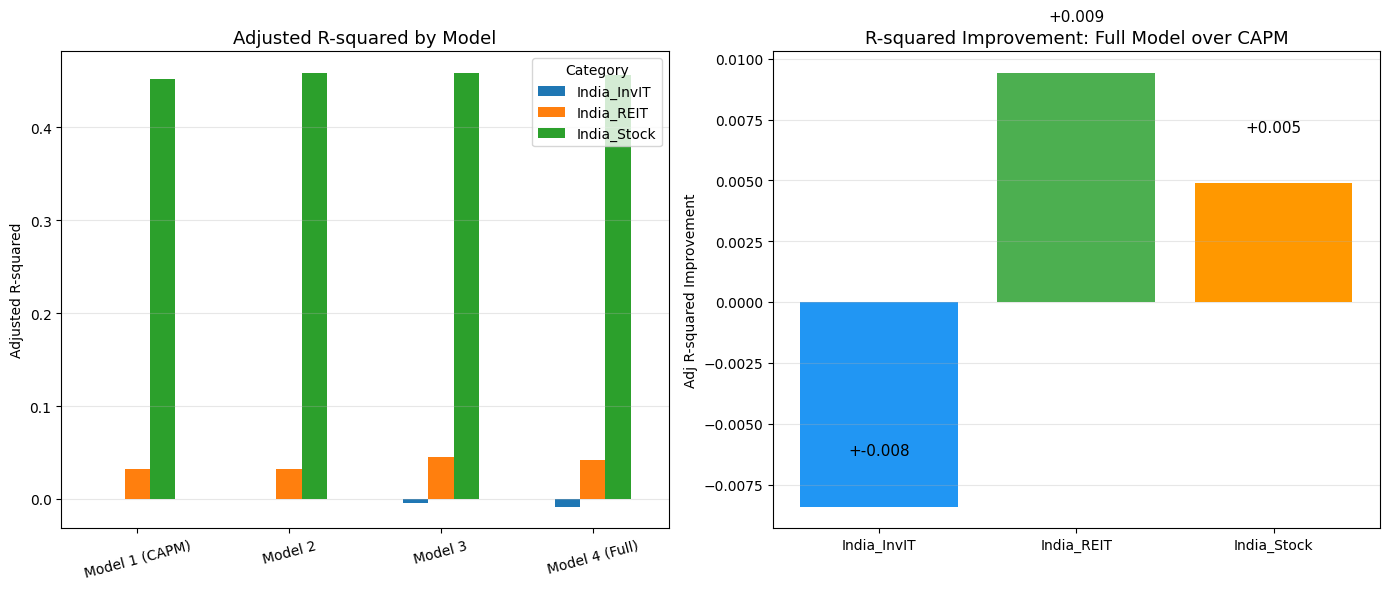

In [17]:
# CELL 17: R-squared comparison bar chart

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Adj R-squared comparison
r2_data = {}
for model_name, model_dict in all_models.items():
    if model_dict:
        r2_data[model_name] = {cat: model_dict[cat]['adj_r_squared'] 
                                for cat in categories if cat in model_dict}

r2_df = pd.DataFrame(r2_data).T
r2_df.plot(kind='bar', ax=axes[0], rot=15)
axes[0].set_title('Adjusted R-squared by Model', fontsize=13)
axes[0].set_ylabel('Adjusted R-squared')
axes[0].legend(title='Category')
axes[0].grid(axis='y', alpha=0.3)

# R-squared improvement from CAPM
if model1_results and model4_results:
    improvement = {}
    for cat in categories:
        if cat in model1_results and cat in model4_results:
            capm_r2 = model1_results[cat]['adj_r_squared']
            full_r2 = model4_results[cat]['adj_r_squared']
            improvement[cat] = full_r2 - capm_r2
    
    colors = ['#2196F3', '#4CAF50', '#FF9800']
    bars = axes[1].bar(improvement.keys(), improvement.values(), color=colors)
    axes[1].set_title('R-squared Improvement: Full Model over CAPM', fontsize=13)
    axes[1].set_ylabel('Adj R-squared Improvement')
    axes[1].grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, improvement.values()):
        axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                    f'+{val:.3f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()


FACTOR LOADING COMPARISON (Full Model)

Beta coefficients:
Category   India_InvIT  India_REIT  India_Stock
Factor                                         
INR_USD        -0.0559     -0.3760      -0.2593
Nifty50         0.0395      0.1462       1.2276
Oil            -0.0003     -0.0047      -0.0163
Yield_10Y      -0.0160      0.0224       0.0588

t-statistics:
Category   India_InvIT  India_REIT  India_Stock
Factor                                         
INR_USD          -0.51       -2.02        -0.98
Nifty50           0.49        2.34        13.37
Oil              -0.01       -0.25        -0.47
Yield_10Y        -0.87        1.51         2.16


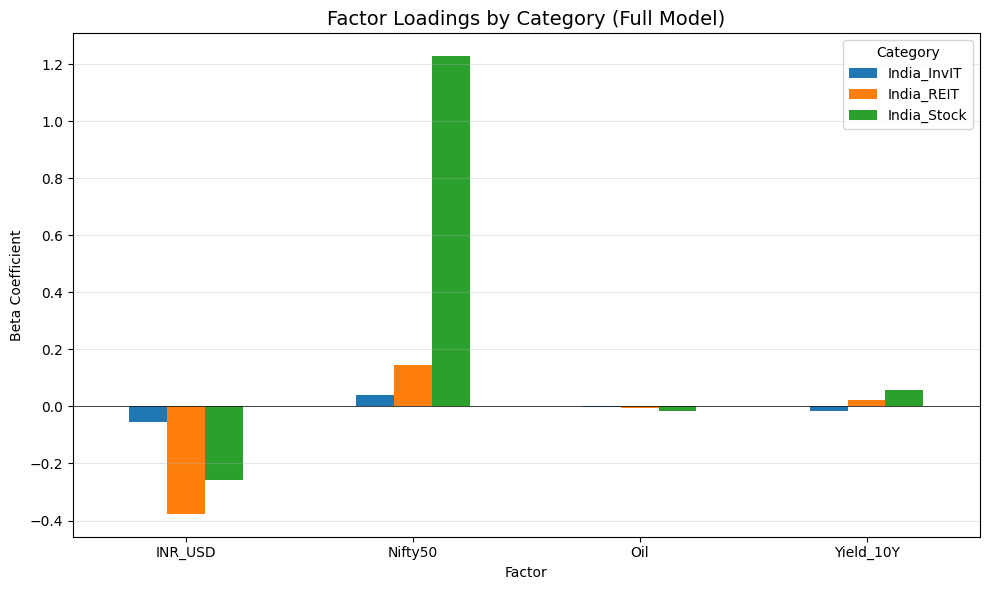

In [18]:
# CELL 18: Factor loading comparison across categories (Full Model)

print("=" * 80)
print("FACTOR LOADING COMPARISON (Full Model)")
print("=" * 80)

if model4_results:
    # Build factor loading table
    loading_data = []
    for cat in categories:
        if cat in model4_results:
            params = model4_results[cat]['params']
            tvals = model4_results[cat]['tvalues']
            pvals = model4_results[cat]['pvalues']
            
            for factor in params.index:
                if factor != 'const':
                    sig = '***' if pvals[factor] < 0.01 else '**' if pvals[factor] < 0.05 else '*' if pvals[factor] < 0.1 else ''
                    loading_data.append({
                        'Category': cat,
                        'Factor': factor,
                        'Beta': params[factor],
                        't-stat': tvals[factor],
                        'p-value': pvals[factor],
                        'Sig': sig
                    })
    
    loading_df = pd.DataFrame(loading_data)
    
    # Pivot for nice display
    pivot_beta = loading_df.pivot(index='Factor', columns='Category', values='Beta').round(4)
    pivot_t = loading_df.pivot(index='Factor', columns='Category', values='t-stat').round(2)
    
    print("\nBeta coefficients:")
    print(pivot_beta.to_string())
    print("\nt-statistics:")
    print(pivot_t.to_string())
    
    # Plot factor loadings
    fig, ax = plt.subplots(figsize=(10, 6))
    pivot_beta.plot(kind='bar', ax=ax, rot=0)
    ax.set_title('Factor Loadings by Category (Full Model)', fontsize=14)
    ax.set_ylabel('Beta Coefficient')
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.legend(title='Category')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


In [19]:
# CELL 19: Rolling regression analysis (52-week window)
# Shows how factor sensitivities change over time

WINDOW = 52  # 52 weeks = ~1 year

print(f"Rolling regression with {WINDOW}-week window")
print(f"Minimum date for first estimate: week {WINDOW}")

# Store rolling betas for each category
rolling_results = {}

for cat in categories:
    y = weekly_portfolios[cat]
    X = weekly_factors[all_factor_cols]
    
    # Storage for rolling coefficients
    rolling_betas = pd.DataFrame(index=y.index[WINDOW:], 
                                  columns=['const'] + all_factor_cols)
    rolling_r2 = pd.Series(index=y.index[WINDOW:], dtype=float)
    
    for i in range(WINDOW, len(y)):
        y_window = y.iloc[i-WINDOW:i]
        X_window = X.iloc[i-WINDOW:i]
        X_const = add_constant(X_window)
        
        try:
            model = OLS(y_window, X_const).fit()
            rolling_betas.iloc[i-WINDOW] = model.params
            rolling_r2.iloc[i-WINDOW] = model.rsquared
        except:
            rolling_betas.iloc[i-WINDOW] = np.nan
            rolling_r2.iloc[i-WINDOW] = np.nan
    
    rolling_results[cat] = {
        'betas': rolling_betas.astype(float),
        'r2': rolling_r2.astype(float)
    }

print("Rolling regressions complete for all categories")


Rolling regression with 52-week window
Minimum date for first estimate: week 52
Rolling regressions complete for all categories


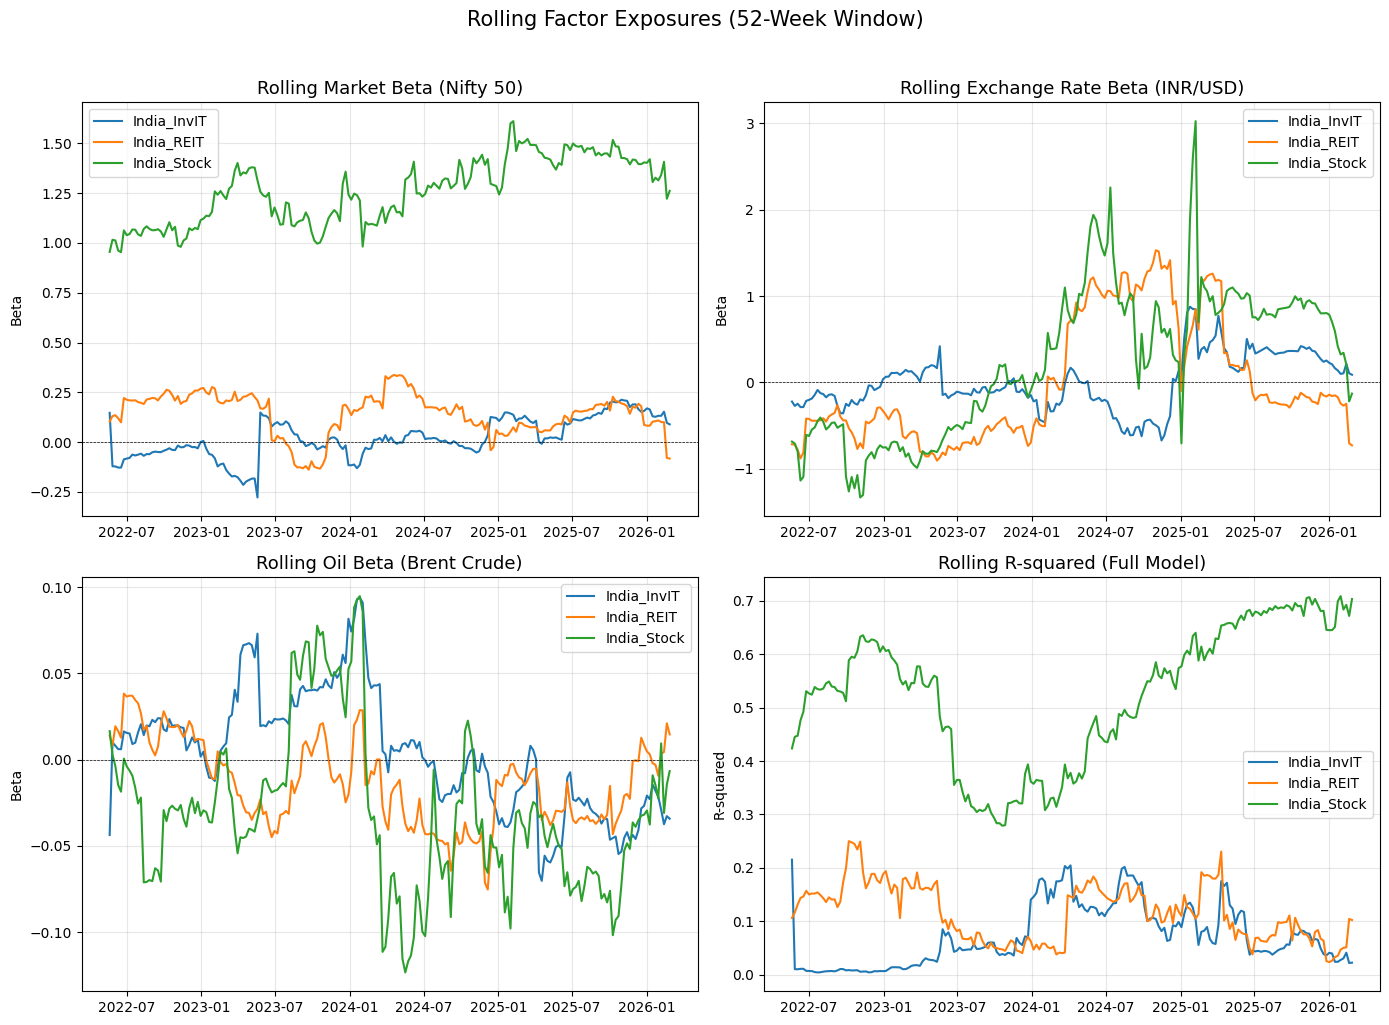

In [20]:
# CELL 20: Plot rolling market beta (Nifty 50) for all categories

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Rolling Market Beta
ax = axes[0, 0]
for cat in categories:
    betas = rolling_results[cat]['betas']
    ax.plot(betas.index, betas['Nifty50'], label=cat, linewidth=1.5)
ax.set_title('Rolling Market Beta (Nifty 50)', fontsize=13)
ax.set_ylabel('Beta')
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Rolling INR/USD Beta
ax = axes[0, 1]
for cat in categories:
    betas = rolling_results[cat]['betas']
    if 'INR_USD' in betas.columns:
        ax.plot(betas.index, betas['INR_USD'], label=cat, linewidth=1.5)
ax.set_title('Rolling Exchange Rate Beta (INR/USD)', fontsize=13)
ax.set_ylabel('Beta')
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.legend()
ax.grid(alpha=0.3)

# Plot 3: Rolling Oil Beta
ax = axes[1, 0]
for cat in categories:
    betas = rolling_results[cat]['betas']
    if 'Oil' in betas.columns:
        ax.plot(betas.index, betas['Oil'], label=cat, linewidth=1.5)
ax.set_title('Rolling Oil Beta (Brent Crude)', fontsize=13)
ax.set_ylabel('Beta')
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.legend()
ax.grid(alpha=0.3)

# Plot 4: Rolling R-squared
ax = axes[1, 1]
for cat in categories:
    r2 = rolling_results[cat]['r2']
    ax.plot(r2.index, r2, label=cat, linewidth=1.5)
ax.set_title('Rolling R-squared (Full Model)', fontsize=13)
ax.set_ylabel('R-squared')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle(f'Rolling Factor Exposures ({WINDOW}-Week Window)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


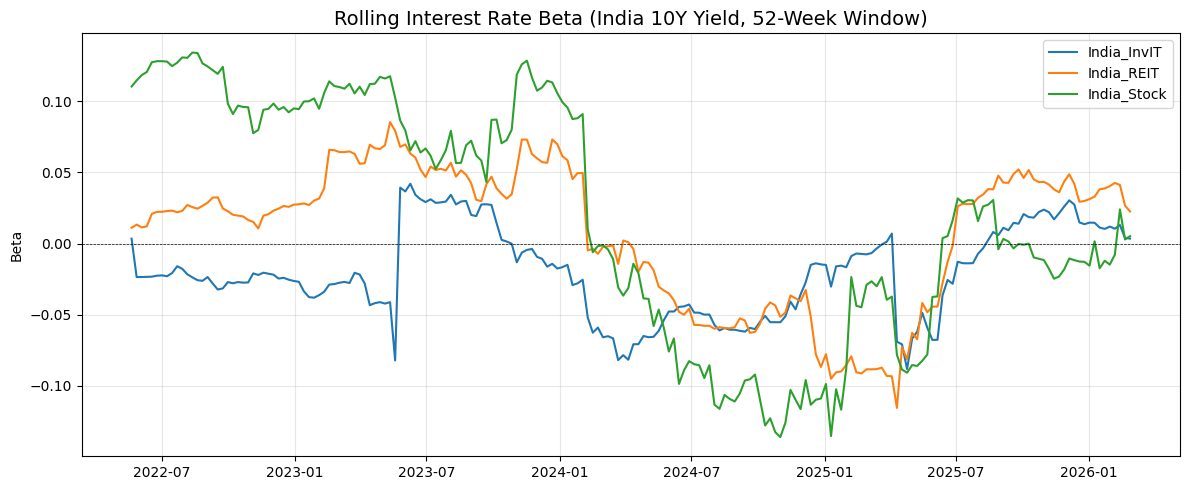

In [21]:
# CELL 21: Rolling Interest Rate Beta (if yield data available)

if 'Yield_10Y' in all_factor_cols:
    fig, ax = plt.subplots(figsize=(12, 5))
    for cat in categories:
        betas = rolling_results[cat]['betas']
        ax.plot(betas.index, betas['Yield_10Y'], label=cat, linewidth=1.5)
    ax.set_title(f'Rolling Interest Rate Beta (India 10Y Yield, {WINDOW}-Week Window)', fontsize=14)
    ax.set_ylabel('Beta')
    ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Yield_10Y not in factors - skipping this plot")
    print("Upload India 10Y yield data and re-run from Cell 7 to include this")


VARIANCE DECOMPOSITION (Full Model)
Category       India_InvIT  India_REIT  India_Stock
Component                                          
INR_USD             0.0003      0.0167       0.0018
Idiosyncratic       0.9919      0.9427       0.5347
Nifty50             0.0016      0.0254       0.4067
Oil                 0.0000      0.0002       0.0005
Yield_10Y           0.0030      0.0068       0.0105


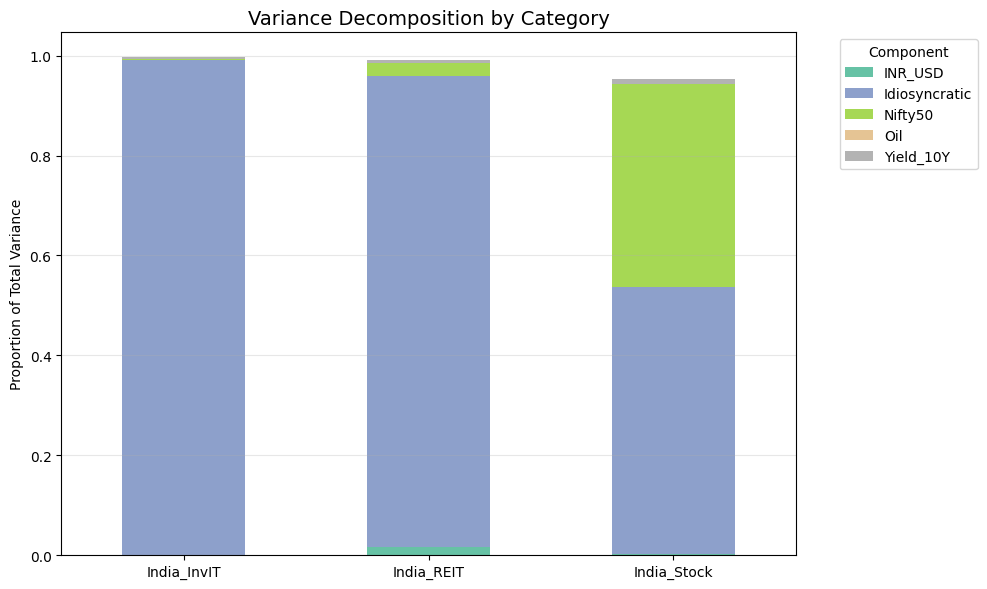

In [22]:
# CELL 22: Variance decomposition
# What proportion of each category's return variance is explained by each factor?

print("=" * 80)
print("VARIANCE DECOMPOSITION (Full Model)")
print("=" * 80)

decomp_data = []

for cat in categories:
    if cat not in model4_results:
        continue
    
    model = model4_results[cat]['model_obj']
    y = weekly_portfolios[cat]
    X = weekly_factors[all_factor_cols]
    
    total_var = y.var()
    
    # Compute marginal contribution of each factor
    # Method: compute R-squared dropping each factor one at a time
    full_r2 = model.rsquared
    
    contributions = {}
    for factor in all_factor_cols:
        # Model without this factor
        remaining = [f for f in all_factor_cols if f != factor]
        X_reduced = add_constant(weekly_factors[remaining])
        reduced_model = OLS(y, X_reduced).fit()
        reduced_r2 = reduced_model.rsquared
        
        # Marginal contribution = full R2 - reduced R2
        contributions[factor] = full_r2 - reduced_r2
    
    # Idiosyncratic (unexplained)
    contributions['Idiosyncratic'] = 1 - full_r2
    
    for factor, contrib in contributions.items():
        decomp_data.append({
            'Category': cat,
            'Component': factor,
            'Proportion': contrib
        })

decomp_df = pd.DataFrame(decomp_data)
pivot_decomp = decomp_df.pivot(index='Component', columns='Category', values='Proportion')
print(pivot_decomp.round(4).to_string())

# Stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
pivot_decomp_t = pivot_decomp.T
colors = plt.cm.Set2(np.linspace(0, 1, len(pivot_decomp_t.columns)))
pivot_decomp_t.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Variance Decomposition by Category', fontsize=14)
ax.set_ylabel('Proportion of Total Variance')
ax.set_xlabel('')
ax.legend(title='Component', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
# CELL 22: Variance decomposition — Shapley values (exact)
#
# Replaces the drop-one marginal R² approach. When regressors are correlated
# (which they are here — Nifty50 vs INR/USD vs Yield all correlated), drop-one
# contributions under-attribute shared variance and don't sum to full R².
# Shapley values (Shapley 1953; for regression, see Lipovetsky & Conklin 2001)
# average marginal contributions over all orderings of factor inclusion and
# DO sum to full R² by construction.

from itertools import combinations
from math import factorial

def shapley_r2_decomp(y_series, X_all_df, factors):
    """Exact Shapley R² decomposition. Returns dict {factor: shapley_R²}.
    Sum of values = full-model R². O(2^K) regressions where K = len(factors)."""
    K = len(factors)
    y_arr = y_series.values
    # Cache R² for each subset to avoid redundant fits
    r2_cache = {(): 0.0}  # R² of constant-only model = 0
    def get_r2(subset):
        key = tuple(sorted(subset))
        if key in r2_cache:
            return r2_cache[key]
        X_sub = add_constant(X_all_df[list(subset)])
        fit = OLS(y_arr, X_sub, missing='drop').fit()
        r2_cache[key] = float(fit.rsquared)
        return r2_cache[key]
    # Shapley value for each factor
    shap = {}
    for f in factors:
        others = [g for g in factors if g != f]
        total = 0.0
        for S_size in range(K):  # |S| = 0, 1, ..., K-1
            w = factorial(S_size) * factorial(K - S_size - 1) / factorial(K)
            for S in combinations(others, S_size):
                total += w * (get_r2(list(S) + [f]) - get_r2(list(S)))
        shap[f] = total
    return shap

decomp_data = []
print("=" * 80)
print("VARIANCE DECOMPOSITION (Shapley R² — exact)")
print("=" * 80)
print(f"Factors: {len(all_factor_cols)}   →   {2**len(all_factor_cols)} subsets per category")
print()

for cat in categories:
    if cat not in model4_results:
        continue
    y = weekly_portfolios[cat]
    full_r2 = float(model4_results[cat]['model_obj'].rsquared)
    # Align factors to y (drop rows with missing)
    X_full = weekly_factors[all_factor_cols].loc[y.index]
    shap = shapley_r2_decomp(y, X_full, all_factor_cols)

    # Sanity check: Shapley values should sum to full R²
    shap_sum = sum(shap.values())
    print(f"  {cat:<18}  full R²={full_r2:.4f}   Σ Shapley={shap_sum:.4f}   "
          f"(|diff|={abs(full_r2 - shap_sum):.2e})")

    for f, v in shap.items():
        decomp_data.append({'Category': cat, 'Component': f, 'Proportion': v})
    decomp_data.append({'Category': cat, 'Component': 'Idiosyncratic',
                        'Proportion': 1 - full_r2})

decomp_df = pd.DataFrame(decomp_data)
pivot_decomp = decomp_df.pivot(index='Component', columns='Category',
                               values='Proportion')
print()
print("Shapley variance decomposition (proportion of total variance):")
print(pivot_decomp.round(4).to_string())

VARIANCE DECOMPOSITION (Shapley R² — exact)
Factors: 4   →   16 subsets per category

  India_InvIT         full R²=0.0081   Σ Shapley=0.0081   (|diff|=0.00e+00)
  India_REIT          full R²=0.0573   Σ Shapley=0.0573   (|diff|=1.11e-16)
  India_Stock         full R²=0.4653   Σ Shapley=0.4653   (|diff|=0.00e+00)

Shapley variance decomposition (proportion of total variance):
Category       India_InvIT  India_REIT  India_Stock
Component                                          
INR_USD             0.0010      0.0231       0.0277
Idiosyncratic       0.9919      0.9427       0.5347
Nifty50             0.0029      0.0308       0.4289
Oil                 0.0000      0.0001       0.0002
Yield_10Y           0.0042      0.0033       0.0085


In [24]:
# ── Clustered-by-date SEs (proper spec for pooled panel with repeated dates) ──
# HAC on a stacked 3-category panel treats (InvIT, t) and (REIT, t) as
# consecutive time-series obs and computes autocovariances across them, which
# isn't what the regression design implies. Clustered-by-date SEs correctly
# allow arbitrary correlation across categories within the same date.
# Reference: Petersen (2009) JFE; Thompson (2011) JFE for double-clustering.

from linearmodels.panel import PanelOLS

# pooled_data already has MultiIndex ('Category', 'Date') from stacked_y
exog_panel = add_constant(pooled_data[X_cols])
dep_panel  = pooled_data['y']

model_cluster = PanelOLS(dep_panel, exog_panel,
                         entity_effects=False,
                         check_rank=False).fit(cov_type='clustered',
                                               cluster_time=True)

# ── Side-by-side comparison of interaction terms ──────────────────────────
print()
print("=" * 80)
print("INTERACTION TERMS — HAC vs clustered-by-date SEs")
print("=" * 80)
print(f"{'Variable':<25} {'Coeff':>10}  "
      f"{'HAC t':>8} {'HAC p':>8}  {'Clust t':>8} {'Clust p':>8}  {'Changed?':>9}")
print("-" * 90)

def _sig(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

for var in model_pooled.params.index:
    if '_x_' not in var:
        continue
    coef = float(model_pooled.params[var])
    t_h  = float(model_pooled.tvalues[var])
    p_h  = float(model_pooled.pvalues[var])
    # linearmodels uses tstats / pvalues
    t_c  = float(model_cluster.tstats[var])
    p_c  = float(model_cluster.pvalues[var])
    # Did significance category change at 5%?
    changed = 'YES' if (p_h < 0.05) != (p_c < 0.05) else ''
    print(f"{var:<25} {coef:>10.6f}  "
          f"{t_h:>8.3f} {p_h:>7.4f}{_sig(p_h):<1}  "
          f"{t_c:>8.3f} {p_c:>7.4f}{_sig(p_c):<1}  {changed:>9}")

print()
print("Read-off:")
print("  If a 'YES' appears in the Changed? column, the HAC-vs-clustered choice")
print("  is material for that interaction. For the dissertation, use clustered-")
print("  by-date SEs as primary (correct spec for this panel structure) and cite")
print("  HAC as robustness.")

# Joint F-tests under clustered SEs
print()
print("Joint F-tests (clustered SEs):")
invit_vars = [v for v in model_cluster.params.index if '_x_InvIT' in v]
reit_vars  = [v for v in model_cluster.params.index if '_x_REIT'  in v]

try:
    ft_invit = model_cluster.wald_test(
        formula=' = '.join([f'{v} = 0' for v in invit_vars]))
    print(f"  H0: All InvIT interactions = 0 | clustered F={ft_invit.stat:.3f}, "
          f"p={ft_invit.pval:.4f}")
except Exception as e:
    print(f"  (Clustered joint test for InvIT unavailable: {type(e).__name__})")

try:
    ft_reit = model_cluster.wald_test(
        formula=' = '.join([f'{v} = 0' for v in reit_vars]))
    print(f"  H0: All REIT interactions = 0  | clustered F={ft_reit.stat:.3f}, "
          f"p={ft_reit.pval:.4f}")
except Exception as e:
    print(f"  (Clustered joint test for REIT unavailable: {type(e).__name__})")

NameError: name 'pooled_data' is not defined

In [ ]:
# CELL 23: Cross-category statistical difference tests
# Test: Are InvIT/REIT factor sensitivities significantly different from Stock?
# Method: Pooled regression with interaction terms

print("=" * 80)
print("CROSS-CATEGORY DIFFERENCE TESTS")
print("Are InvIT/REIT factor sensitivities different from Stock?")
print("=" * 80)

# Stack the data: combine all three categories
stacked_y = pd.concat([
    weekly_portfolios['India_InvIT'],
    weekly_portfolios['India_REIT'],
    weekly_portfolios['India_Stock']
], keys=['InvIT', 'REIT', 'Stock'], names=['Category', 'Date'])

stacked_X = pd.concat([weekly_factors] * 3, 
                       keys=['InvIT', 'REIT', 'Stock'], 
                       names=['Category', 'Date'])

# Create dummy interactions
# Base category = Stock (so InvIT and REIT dummies measure DIFFERENCE from Stock)
pooled_data = pd.DataFrame(index=stacked_y.index)
pooled_data['y'] = stacked_y.values

# Dummies
pooled_data['D_InvIT'] = (pooled_data.index.get_level_values('Category') == 'InvIT').astype(int)
pooled_data['D_REIT'] = (pooled_data.index.get_level_values('Category') == 'REIT').astype(int)

# Base factors (Stock coefficients)
for col in all_factor_cols:
    pooled_data[col] = stacked_X[col].values

# Interaction terms (difference from Stock)
for col in all_factor_cols:
    pooled_data[f'{col}_x_InvIT'] = pooled_data[col] * pooled_data['D_InvIT']
    pooled_data[f'{col}_x_REIT'] = pooled_data[col] * pooled_data['D_REIT']

# Run pooled regression
X_cols = all_factor_cols.copy()
for col in all_factor_cols:
    X_cols.append(f'{col}_x_InvIT')
    X_cols.append(f'{col}_x_REIT')

X_pooled = add_constant(pooled_data[X_cols])
model_pooled = OLS(pooled_data['y'], X_pooled).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

# Print results focusing on interaction terms
print("\nInteraction terms (difference from Stock category):")
print(f"{'Variable':<25} {'Coeff':>10} {'t-stat':>10} {'p-value':>10} {'Sig':>5}")
print("-" * 65)
for var in model_pooled.params.index:
    if '_x_' in var:
        coef = model_pooled.params[var]
        t = model_pooled.tvalues[var]
        p = model_pooled.pvalues[var]
        sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
        print(f"{var:<25} {coef:>10.6f} {t:>10.3f} {p:>10.4f} {sig:>5}")

# Joint F-test: all InvIT interactions = 0
invit_vars = [v for v in model_pooled.params.index if '_x_InvIT' in v]
reit_vars = [v for v in model_pooled.params.index if '_x_REIT' in v]

print("\n" + "-" * 65)
print("Joint F-tests:")
try:
    f_test_invit = model_pooled.f_test(' = '.join([f'{v} = 0' for v in invit_vars]))
    print(f"  H0: All InvIT interactions = 0  =>  F={f_test_invit.fvalue[0][0]:.3f}, p={f_test_invit.pvalue:.4f}")
except:
    # Alternative: test each individually
    print("  (Joint test not available - see individual p-values above)")

try:
    f_test_reit = model_pooled.f_test(' = '.join([f'{v} = 0' for v in reit_vars]))
    print(f"  H0: All REIT interactions = 0   =>  F={f_test_reit.fvalue[0][0]:.3f}, p={f_test_reit.pvalue:.4f}")
except:
    print("  (Joint test not available - see individual p-values above)")


CROSS-CATEGORY DIFFERENCE TESTS
Are InvIT/REIT factor sensitivities different from Stock?

Interaction terms (difference from Stock category):
Variable                       Coeff     t-stat    p-value   Sig
-----------------------------------------------------------------
Nifty50_x_InvIT            -1.197536     -9.632     0.0000   ***
Nifty50_x_REIT             -1.082122     -9.944     0.0000   ***
INR_USD_x_InvIT             0.164897      0.596     0.5514      
INR_USD_x_REIT             -0.119625     -0.383     0.7015      
Oil_x_InvIT                 0.015648      0.390     0.6965      
Oil_x_REIT                  0.011532      0.290     0.7716      
Yield_10Y_x_InvIT          -0.075496     -2.277     0.0228    **
Yield_10Y_x_REIT           -0.036404     -1.171     0.2417      

-----------------------------------------------------------------
Joint F-tests:
  (Joint test not available - see individual p-values above)
  (Joint test not available - see individual p-values above)


In [ ]:
# CELL 24: Regression diagnostics for Full Model

print("=" * 80)
print("REGRESSION DIAGNOSTICS (Full Model)")
print("=" * 80)

for cat in categories:
    if cat not in model4_results:
        continue
    
    model = model4_results[cat]['model_obj']
    
    print(f"\n--- {cat} ---")
    
    # 1. Durbin-Watson (autocorrelation)
    dw = durbin_watson(model.resid)
    print(f"  Durbin-Watson: {dw:.3f} (close to 2 = no autocorrelation)")
    
    # 2. Breusch-Pagan (heteroskedasticity)
    try:
        bp_stat, bp_pval, _, _ = het_breuschpagan(model.resid, model.model.exog)
        print(f"  Breusch-Pagan: stat={bp_stat:.3f}, p={bp_pval:.4f} {'(heteroskedastic)' if bp_pval < 0.05 else '(homoskedastic)'}")
    except:
        print("  Breusch-Pagan: could not compute")
    
    # 3. Jarque-Bera (normality of residuals)
    jb_stat, jb_pval = stats.jarque_bera(model.resid)
    print(f"  Jarque-Bera: stat={jb_stat:.3f}, p={jb_pval:.4f} {'(non-normal)' if jb_pval < 0.05 else '(normal)'}")
    
    # 4. Breusch-Godfrey (serial correlation)
    try:
        bg_stat, bg_pval, _, _ = acorr_breusch_godfrey(model, nlags=4)
        print(f"  Breusch-Godfrey (4 lags): stat={bg_stat:.3f}, p={bg_pval:.4f}")
    except:
        print("  Breusch-Godfrey: could not compute")


REGRESSION DIAGNOSTICS (Full Model)

--- India_InvIT ---
  Durbin-Watson: 1.880 (close to 2 = no autocorrelation)
  Breusch-Pagan: stat=3.777, p=0.4371 (homoskedastic)
  Jarque-Bera: stat=73960.122, p=0.0000 (non-normal)
  Breusch-Godfrey (4 lags): stat=2.705, p=0.6083

--- India_REIT ---
  Durbin-Watson: 2.073 (close to 2 = no autocorrelation)
  Breusch-Pagan: stat=3.931, p=0.4155 (homoskedastic)
  Jarque-Bera: stat=39.589, p=0.0000 (non-normal)
  Breusch-Godfrey (4 lags): stat=2.166, p=0.7052

--- India_Stock ---
  Durbin-Watson: 2.134 (close to 2 = no autocorrelation)
  Breusch-Pagan: stat=3.398, p=0.4935 (homoskedastic)
  Jarque-Bera: stat=11.220, p=0.0037 (non-normal)
  Breusch-Godfrey (4 lags): stat=3.117, p=0.5384


In [ ]:
# CELL 25: Summary of Phase 2 findings

print("=" * 80)
print("PHASE 2 SUMMARY: MULTI-FACTOR ANALYSIS OF INDIAN INFRASTRUCTURE")
print("=" * 80)

print("\n1. MODEL COMPARISON (Adj R-squared):")
for cat in categories:
    capm_r2 = model1_results[cat]['adj_r_squared'] if cat in model1_results else 'N/A'
    full_r2 = model4_results[cat]['adj_r_squared'] if cat in model4_results else 'N/A'
    if isinstance(capm_r2, float) and isinstance(full_r2, float):
        improvement = full_r2 - capm_r2
        print(f"  {cat}: CAPM={capm_r2:.4f} -> Full={full_r2:.4f} (improvement: +{improvement:.4f})")

print("\n2. KEY FACTOR SENSITIVITIES (Full Model):")
for cat in categories:
    if cat in model4_results:
        params = model4_results[cat]['params']
        pvals = model4_results[cat]['pvalues']
        print(f"\n  {cat}:")
        for var in params.index:
            if var != 'const':
                sig = '***' if pvals[var] < 0.01 else '**' if pvals[var] < 0.05 else '*' if pvals[var] < 0.1 else 'ns'
                print(f"    {var}: {params[var]:.4f} ({sig})")

print("\n3. CONNECTING TO PHASE 1:")
print("   Phase 1 found >97% domestic variance for all Indian categories.")
print("   Phase 2 investigates WHAT domestic factors drive these returns.")
print("   Key question: Do InvITs/REITs respond differently to macro factors than Stocks?")

print("\n4. NEXT STEPS:")
print("   - Upload India 10Y yield data (if not yet available) for interest rate analysis")
print("   - Phase 3: ML prediction with enriched feature set")
print("   - Phase 4: Portfolio optimization using factor model covariances")

print("\n" + "=" * 80)
print("PHASE 2 COMPLETE")
print("=" * 80)


PHASE 2 SUMMARY: MULTI-FACTOR ANALYSIS OF INDIAN INFRASTRUCTURE

1. MODEL COMPARISON (Adj R-squared):
  India_InvIT: CAPM=0.0003 -> Full=-0.0081 (improvement: +-0.0084)
  India_REIT: CAPM=0.0325 -> Full=0.0419 (improvement: +0.0094)
  India_Stock: CAPM=0.4517 -> Full=0.4566 (improvement: +0.0049)

2. KEY FACTOR SENSITIVITIES (Full Model):

  India_InvIT:
    Nifty50: 0.0395 (ns)
    INR_USD: -0.0559 (ns)
    Oil: -0.0003 (ns)
    Yield_10Y: -0.0160 (ns)

  India_REIT:
    Nifty50: 0.1462 (**)
    INR_USD: -0.3760 (**)
    Oil: -0.0047 (ns)
    Yield_10Y: 0.0224 (ns)

  India_Stock:
    Nifty50: 1.2276 (***)
    INR_USD: -0.2593 (ns)
    Oil: -0.0163 (ns)
    Yield_10Y: 0.0588 (**)

3. CONNECTING TO PHASE 1:
   Phase 1 found >97% domestic variance for all Indian categories.
   Phase 2 investigates WHAT domestic factors drive these returns.
   Key question: Do InvITs/REITs respond differently to macro factors than Stocks?

4. NEXT STEPS:
   - Upload India 10Y yield data (if not yet avail

In [ ]:
# CELL 26: Export all Phase 2 results

import os
os.makedirs('phase2_results', exist_ok=True)

# 1. Export weekly data
weekly_portfolios.to_csv('phase2_results/weekly_portfolios.csv')
weekly_factors.to_csv('phase2_results/weekly_factors.csv')

# 2. Export model comparison
comparison_df.to_csv('phase2_results/model_comparison.csv')

# 3. Export full model coefficients
full_model_summary = []
for cat in categories:
    if cat in model4_results:
        params = model4_results[cat]['params']
        tvals = model4_results[cat]['tvalues']
        pvals = model4_results[cat]['pvalues']
        for var in params.index:
            full_model_summary.append({
                'Category': cat,
                'Factor': var,
                'Beta': params[var],
                't_stat': tvals[var],
                'p_value': pvals[var]
            })
pd.DataFrame(full_model_summary).to_csv('phase2_results/full_model_coefficients.csv', index=False)

# 4. Export variance decomposition
decomp_df.to_csv('phase2_results/variance_decomposition.csv', index=False)

# 5. Summary text file
with open('phase2_results/PHASE2_SUMMARY.txt', 'w') as f:
    f.write("PHASE 2: MULTI-FACTOR ANALYSIS - RESULTS SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Data: Weekly frequency, {weekly_portfolios.index[0].date()} to {weekly_portfolios.index[-1].date()}\n")
    f.write(f"Observations: {len(weekly_portfolios)}\n")
    f.write(f"Factors: {all_factor_cols}\n\n")
    
    f.write("Adjusted R-squared Comparison:\n")
    for cat in categories:
        if cat in model1_results and cat in model4_results:
            f.write(f"  {cat}: CAPM={model1_results[cat]['adj_r_squared']:.4f}, Full={model4_results[cat]['adj_r_squared']:.4f}\n")

print("All Phase 2 results exported to phase2_results/")
print("Files created:")
for f in os.listdir('phase2_results'):
    print(f"  {f}")


All Phase 2 results exported to phase2_results/
Files created:
  full_model_coefficients.csv
  model_comparison.csv
  PHASE2_SUMMARY.txt
  variance_decomposition.csv
  weekly_factors.csv
  weekly_portfolios.csv


# PHASE 2 EXTENSION: Additional Factors, Monthly Frequency & Lagged Analysis

**Why:** The baseline macro factors (Nifty50, Yield_10Y, INR_USD, Oil) explain very little of InvIT/REIT returns. This extension tries three improvements:

1. **More factors** — Nifty Realty Index, term spread, VIX India
2. **Monthly frequency** — CRR (1986) used monthly; thin trading may cause noise at weekly
3. **Lagged factors** — InvITs are thinly traded, so they may respond with a lag


In [ ]:
# CELL 27: Download additional factor data
# Adding: Nifty Realty, India VIX, short-term rate proxy

print("Downloading additional factor data...")
print("=" * 60)

# Nifty Realty Index - sector-specific market factor (Clayton & MacKinnon 2003)
realty_tickers = ['NIFTYREALTY.NS', '^CNXREALTY']
nifty_realty_data = None
for ticker in realty_tickers:
    try:
        temp = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
        if not temp.empty and len(temp) > 100:
            nifty_realty_data = temp
            print(f"  Nifty Realty ({ticker}): {len(temp)} days")
            break
    except:
        pass
if nifty_realty_data is None:
    print("  Nifty Realty: NOT FOUND - trying alternative")
    # Try using a Realty ETF as proxy
    for ticker in ['SETFNIF50.NS', 'REALTYETF.NS']:
        try:
            temp = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
            if not temp.empty and len(temp) > 100:
                nifty_realty_data = temp
                print(f"  Realty proxy ({ticker}): {len(temp)} days")
                break
        except:
            pass
if nifty_realty_data is None:
    print("  Nifty Realty: NOT AVAILABLE")

# India VIX - fear/volatility gauge
india_vix_data = None
for ticker in ['^INDIAVIX', 'INDIAVIX.NS']:
    try:
        temp = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
        if not temp.empty and len(temp) > 100:
            india_vix_data = temp
            print(f"  India VIX ({ticker}): {len(temp)} days")
            break
    except:
        pass
if india_vix_data is None:
    print("  India VIX: NOT AVAILABLE")

# Gold - alternative safe haven asset (relevant for Indian investors)
gold_data = None
for ticker in ['GC=F', 'GOLDBEES.NS']:
    try:
        temp = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
        if not temp.empty and len(temp) > 100:
            gold_data = temp
            print(f"  Gold ({ticker}): {len(temp)} days")
            break
    except:
        pass
if gold_data is None:
    print("  Gold: NOT AVAILABLE")

# Nifty Infrastructure Index - infra-specific benchmark
nifty_infra_data = None
for ticker in ['NIFTYINFRA.NS', '^CNXINFRA']:
    try:
        temp = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
        if not temp.empty and len(temp) > 100:
            nifty_infra_data = temp
            print(f"  Nifty Infra ({ticker}): {len(temp)} days")
            break
    except:
        pass
if nifty_infra_data is None:
    print("  Nifty Infra: NOT AVAILABLE")

print("\nDownload complete.")


$NIFTYREALTY.NS: possibly delisted; no timezone found

1 Failed download:
['NIFTYREALTY.NS']: possibly delisted; no timezone found


  Nifty Realty (^CNXREALTY): 1370 days
  India VIX (^INDIAVIX): 1370 days
  Gold (GC=F): 1407 days


$NIFTYINFRA.NS: possibly delisted; no timezone found

1 Failed download:
['NIFTYINFRA.NS']: possibly delisted; no timezone found


  Nifty Infra (^CNXINFRA): 1370 days

Download complete.


In [ ]:
# CELL 28: Build extended daily factor set

print("Building extended factor set...")

# Start with existing factors
extended_daily = daily_factors.copy()

# Add Nifty Realty return
if nifty_realty_data is not None:
    realty_close = get_close(nifty_realty_data)
    realty_ret = np.log(realty_close / realty_close.shift(1)).dropna()
    extended_daily['Realty'] = realty_ret
    print(f"  Added: Nifty Realty ({len(realty_ret)} days)")

# Add India VIX change
if india_vix_data is not None:
    vix_close = get_close(india_vix_data)
    vix_change = vix_close.diff().dropna()  # Level change, not log return
    extended_daily['VIX_India'] = vix_change
    print(f"  Added: India VIX change ({len(vix_change)} days)")

# Add Gold return
if gold_data is not None:
    gold_close = get_close(gold_data)
    gold_ret = np.log(gold_close / gold_close.shift(1)).dropna()
    extended_daily['Gold'] = gold_ret
    print(f"  Added: Gold ({len(gold_ret)} days)")

# Add Nifty Infra return
if nifty_infra_data is not None:
    infra_close = get_close(nifty_infra_data)
    infra_ret = np.log(infra_close / infra_close.shift(1)).dropna()
    extended_daily['NiftyInfra'] = infra_ret
    print(f"  Added: Nifty Infra ({len(infra_ret)} days)")

# Term spread proxy: 10Y yield level itself as a factor 
# (since we don't have short-term rate, we use yield level)
extended_daily['Yield_Level'] = india_10y['Close']
print(f"  Added: Yield Level")

# Drop NaN
extended_daily = extended_daily.dropna()
print(f"\nExtended daily factors: {extended_daily.shape}")
print(f"Columns: {list(extended_daily.columns)}")
print(f"Date range: {extended_daily.index[0].date()} to {extended_daily.index[-1].date()}")


Building extended factor set...
  Added: Nifty Realty (1369 days)
  Added: India VIX change (1369 days)
  Added: Gold (1406 days)
  Added: Nifty Infra (1369 days)
  Added: Yield Level

Extended daily factors: (1307, 9)
Columns: ['Nifty50', 'INR_USD', 'Oil', 'Yield_10Y', 'Realty', 'VIX_India', 'Gold', 'NiftyInfra', 'Yield_Level']
Date range: 2020-07-28 to 2026-02-27


In [ ]:
# CELL 29: Aggregate extended factors to weekly

# Separate level variables from return/change variables
return_cols = [c for c in extended_daily.columns if c != 'Yield_Level']
level_cols = [c for c in extended_daily.columns if c == 'Yield_Level']

# Sum returns/changes within week
weekly_ext_factors = extended_daily[return_cols].resample('W-FRI').sum()

# For level variables, take the last value of the week
if level_cols:
    for col in level_cols:
        weekly_ext_factors[col] = extended_daily[col].resample('W-FRI').last()

weekly_ext_factors = weekly_ext_factors.dropna()

# Align with portfolio data
common_dates_ext = weekly_portfolios.index.intersection(weekly_ext_factors.index)
weekly_port_ext = weekly_portfolios.loc[common_dates_ext]
weekly_ext_factors = weekly_ext_factors.loc[common_dates_ext]

print(f"Extended weekly data:")
print(f"  Portfolios: {weekly_port_ext.shape}")
print(f"  Factors: {weekly_ext_factors.shape}")
print(f"  Columns: {list(weekly_ext_factors.columns)}")

# Correlation with portfolios
print("\nCorrelation of new factors with portfolios:")
new_factors = [c for c in weekly_ext_factors.columns if c not in ['Nifty50', 'INR_USD', 'Oil', 'Yield_10Y']]
if new_factors:
    corr_new = pd.concat([weekly_port_ext, weekly_ext_factors[new_factors]], axis=1).corr()
    print(corr_new.loc[categories, new_factors].round(3).to_string())
else:
    print("No new factors were added successfully")


Extended weekly data:
  Portfolios: (250, 3)
  Factors: (250, 9)
  Columns: ['Nifty50', 'INR_USD', 'Oil', 'Yield_10Y', 'Realty', 'VIX_India', 'Gold', 'NiftyInfra', 'Yield_Level']

Correlation of new factors with portfolios:
             Realty  VIX_India   Gold  NiftyInfra  Yield_Level
India_InvIT   0.133     -0.051 -0.014       0.061       -0.180
India_REIT    0.166     -0.167  0.042       0.229       -0.144
India_Stock   0.604     -0.357  0.028       0.812        0.003


In [ ]:
# CELL 30: Extended model with all available factors

print("=" * 80)
print("EXTENDED MODEL: All Available Factors (Weekly)")
print("=" * 80)

extended_factor_cols = list(weekly_ext_factors.columns)
# Remove Yield_Level if Yield_10Y already present (avoid redundancy)
if 'Yield_10Y' in extended_factor_cols and 'Yield_Level' in extended_factor_cols:
    extended_factor_cols.remove('Yield_Level')

print(f"Factors: {extended_factor_cols}")

extended_results = {}
for cat in categories:
    y = weekly_port_ext[cat]
    X = weekly_ext_factors[extended_factor_cols]
    result = run_regression(y, X, cat, 'Extended Model')
    extended_results[cat] = result
    print_regression_results(result)

# Compare R-squared: Baseline vs Extended
print("\n" + "=" * 80)
print("R-SQUARED COMPARISON: Baseline (4 factors) vs Extended")
print("=" * 80)
for cat in categories:
    base_r2 = model4_results[cat]['adj_r_squared'] if cat in model4_results else 'N/A'
    ext_r2 = extended_results[cat]['adj_r_squared'] if cat in extended_results else 'N/A'
    if isinstance(base_r2, float) and isinstance(ext_r2, float):
        print(f"  {cat}: Baseline AdjR2={base_r2:.4f} -> Extended AdjR2={ext_r2:.4f} (change: {ext_r2-base_r2:+.4f})")


EXTENDED MODEL: All Available Factors (Weekly)
Factors: ['Nifty50', 'INR_USD', 'Oil', 'Yield_10Y', 'Realty', 'VIX_India', 'Gold', 'NiftyInfra']

Dependent Variable: India_InvIT  |  Model: Extended Model
Observations: 250  |  R-squared: 0.0243  |  Adj R-squared: -0.0081
AIC: -1352.50  |  BIC: -1320.81  |  DW: 1.871
F-stat: 1.443  (p=0.1794)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.001877   0.000965      1.945     0.0517     *
Nifty50           0.004660   0.136020      0.034     0.9727      
INR_USD          -0.071562   0.114780     -0.623     0.5330      
Oil              -0.000529   0.020164     -0.026     0.9791      
Yield_10Y        -0.014227   0.018530     -0.768     0.4426      
Realty            0.072339   0.038332      1.887     0.0591     *
VIX_India        -0.000021   0.000467     -0.044     0

## Monthly Frequency Analysis
CRR (1986) used monthly data. Thin trading in InvITs/REITs may cause noise at weekly frequency. Let's test if monthly data tells a different story.


In [ ]:
# CELL 31: Aggregate to monthly frequency and run all models

print("=" * 80)
print("MONTHLY FREQUENCY ANALYSIS")
print("=" * 80)

# Monthly portfolio returns (use 'ME' for month-end in newer pandas)
monthly_portfolios = daily_portfolios.resample('ME').sum().dropna()

# Monthly factor returns/changes
monthly_factors = pd.DataFrame()
for col in daily_factors.columns:
    monthly_factors[col] = daily_factors[col].resample('ME').sum()

monthly_factors = monthly_factors.dropna()

# Align
common_months = monthly_portfolios.index.intersection(monthly_factors.index)
monthly_portfolios = monthly_portfolios.loc[common_months]
monthly_factors = monthly_factors.loc[common_months]

print(f"Monthly data: {len(monthly_portfolios)} months")
print(f"Date range: {monthly_portfolios.index[0].date()} to {monthly_portfolios.index[-1].date()}")
print(f"Factors: {list(monthly_factors.columns)}")

# Run all 4 models at monthly frequency
monthly_model_results = {}
model_specs = {
    'CAPM': ['Nifty50'],
    'CAPM+Yield': ['Nifty50', 'Yield_10Y'],
    'CAPM+Yield+INR': ['Nifty50', 'Yield_10Y', 'INR_USD'],
    'Full': list(monthly_factors.columns)
}

for model_name, factors in model_specs.items():
    print(f"\n{'='*70}")
    print(f"MONTHLY MODEL: {model_name}")
    print(f"{'='*70}")
    monthly_model_results[model_name] = {}
    for cat in categories:
        y = monthly_portfolios[cat]
        X = monthly_factors[factors]
        result = run_regression(y, X, cat, f'Monthly {model_name}')
        monthly_model_results[model_name][cat] = result
        print_regression_results(result)

MONTHLY FREQUENCY ANALYSIS
Monthly data: 58 months
Date range: 2021-05-31 to 2026-02-28
Factors: ['Nifty50', 'INR_USD', 'Oil', 'Yield_10Y']

MONTHLY MODEL: CAPM

Dependent Variable: India_InvIT  |  Model: Monthly CAPM
Observations: 58  |  R-squared: 0.0471  |  Adj R-squared: 0.0301
AIC: -214.42  |  BIC: -210.30  |  DW: 2.049
F-stat: 1.858  (p=0.1783)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.005876   0.005299      1.109     0.2675      
Nifty50           0.227465   0.166871      1.363     0.1728      

Dependent Variable: India_REIT  |  Model: Monthly CAPM
Observations: 58  |  R-squared: 0.0000  |  Adj R-squared: -0.0179
AIC: -246.60  |  BIC: -242.48  |  DW: 1.928
F-stat: 0.000  (p=0.9964)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-

WEEKLY vs MONTHLY R-SQUARED COMPARISON

Weekly (from earlier analysis):
  Model                     InvIT       REIT      Stock
  --------------------------------------------------
  CAPM                     0.0003     0.0325     0.4517
  Full (4 factors)        -0.0081     0.0419     0.4566

Monthly:
  Model                     InvIT       REIT      Stock
  --------------------------------------------------
  CAPM                     0.0301    -0.0179     0.4361
  CAPM+Yield               0.0129    -0.0296     0.4260
  CAPM+Yield+INR          -0.0046    -0.0470     0.4156
  Full                    -0.0032    -0.0219     0.4367


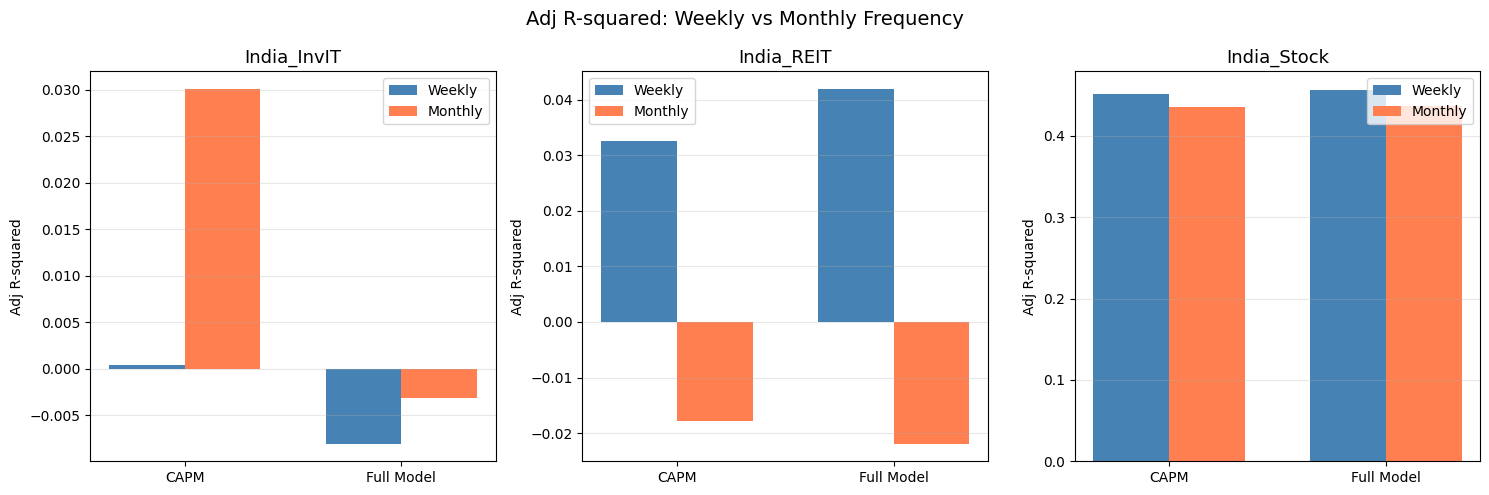

In [ ]:
# CELL 32: Monthly vs Weekly R-squared comparison

print("=" * 80)
print("WEEKLY vs MONTHLY R-SQUARED COMPARISON")
print("=" * 80)

print("\nWeekly (from earlier analysis):")
print(f"  {'Model':<20} {'InvIT':>10} {'REIT':>10} {'Stock':>10}")
print(f"  {'-'*50}")
weekly_models = {
    'CAPM': model1_results,
    'Full (4 factors)': model4_results
}
for mname, mdict in weekly_models.items():
    vals = [f"{mdict[cat]['adj_r_squared']:.4f}" if cat in mdict else 'N/A' for cat in categories]
    print(f"  {mname:<20} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10}")

print("\nMonthly:")
print(f"  {'Model':<20} {'InvIT':>10} {'REIT':>10} {'Stock':>10}")
print(f"  {'-'*50}")
for mname, mdict in monthly_model_results.items():
    vals = [f"{mdict[cat]['adj_r_squared']:.4f}" if cat in mdict else 'N/A' for cat in categories]
    print(f"  {mname:<20} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10}")

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, cat in enumerate(categories):
    weekly_r2 = [model1_results[cat]['adj_r_squared'], model4_results[cat]['adj_r_squared']]
    monthly_r2 = [monthly_model_results['CAPM'][cat]['adj_r_squared'], 
                  monthly_model_results['Full'][cat]['adj_r_squared']]
    
    x = np.arange(2)
    width = 0.35
    axes[i].bar(x - width/2, weekly_r2, width, label='Weekly', color='steelblue')
    axes[i].bar(x + width/2, monthly_r2, width, label='Monthly', color='coral')
    axes[i].set_title(cat, fontsize=13)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(['CAPM', 'Full Model'])
    axes[i].set_ylabel('Adj R-squared')
    axes[i].legend()
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Adj R-squared: Weekly vs Monthly Frequency', fontsize=14)
plt.tight_layout()
plt.show()


## Lagged Factor Analysis
InvITs and REITs are thinly traded. Their prices may not immediately reflect macro news. Testing whether lagged factors have predictive power.


In [ ]:
# CELL 33: Lagged factor analysis (weekly)
# Test if LAST WEEK's factors predict THIS WEEK's returns

print("=" * 80)
print("LAGGED FACTOR ANALYSIS (Weekly)")
print("Does last week's macro change predict this week's return?")
print("=" * 80)

# Create lagged factors
lagged_factors = weekly_factors.shift(1)  # Last week's values
lagged_factors.columns = [f'{c}_lag1' for c in lagged_factors.columns]

# Combine contemporaneous and lagged
combined_factors = pd.concat([weekly_factors, lagged_factors], axis=1).dropna()

# Align with portfolios
common_lag = weekly_portfolios.index.intersection(combined_factors.index)
port_lag = weekly_portfolios.loc[common_lag]
combined_factors = combined_factors.loc[common_lag]

print(f"Data: {len(port_lag)} weeks (lost 1 week to lagging)")

# Model A: Only lagged factors (pure prediction)
print("\n--- Model A: LAGGED FACTORS ONLY (pure prediction) ---")
lag_cols = [c for c in combined_factors.columns if '_lag1' in c]
lag_only_results = {}

for cat in categories:
    y = port_lag[cat]
    X = combined_factors[lag_cols]
    result = run_regression(y, X, cat, 'Lagged Only')
    lag_only_results[cat] = result
    print_regression_results(result)

# Model B: Contemporaneous + Lagged (full model)
print("\n--- Model B: CONTEMPORANEOUS + LAGGED FACTORS ---")
all_cols = list(combined_factors.columns)
contemp_lag_results = {}

for cat in categories:
    y = port_lag[cat]
    X = combined_factors[all_cols]
    result = run_regression(y, X, cat, 'Contemp + Lagged')
    contemp_lag_results[cat] = result
    print_regression_results(result)


LAGGED FACTOR ANALYSIS (Weekly)
Does last week's macro change predict this week's return?
Data: 249 weeks (lost 1 week to lagging)

--- Model A: LAGGED FACTORS ONLY (pure prediction) ---

Dependent Variable: India_InvIT  |  Model: Lagged Only
Observations: 249  |  R-squared: 0.0900  |  Adj R-squared: 0.0750
AIC: -1377.94  |  BIC: -1360.35  |  DW: 1.880
F-stat: 1.253  (p=0.2893)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.001522   0.001120      1.359     0.1740      
Nifty50_lag1      0.194581   0.119115      1.634     0.1024      
INR_USD_lag1     -0.443410   0.256313     -1.730     0.0836     *
Oil_lag1         -0.007092   0.017739     -0.400     0.6893      
Yield_10Y_lag1    0.049149   0.038993      1.260     0.2075      

Dependent Variable: India_REIT  |  Model: Lagged Only
Observations: 249  |  R-sq

In [ ]:
# CELL 34: Lagged factor analysis (monthly)
# Monthly may show stronger lagged effects

print("=" * 80)
print("LAGGED FACTOR ANALYSIS (Monthly)")
print("Does last month's macro change predict this month's return?")
print("=" * 80)

# Create monthly lagged factors
monthly_lagged = monthly_factors.shift(1)
monthly_lagged.columns = [f'{c}_lag1' for c in monthly_lagged.columns]

monthly_combined = pd.concat([monthly_factors, monthly_lagged], axis=1).dropna()

common_mlag = monthly_portfolios.index.intersection(monthly_combined.index)
port_mlag = monthly_portfolios.loc[common_mlag]
monthly_combined = monthly_combined.loc[common_mlag]

print(f"Data: {len(port_mlag)} months")

# Lagged only
print("\n--- LAGGED FACTORS ONLY (monthly, pure prediction) ---")
mlag_cols = [c for c in monthly_combined.columns if '_lag1' in c]
mlag_results = {}

for cat in categories:
    y = port_mlag[cat]
    X = monthly_combined[mlag_cols]
    result = run_regression(y, X, cat, 'Monthly Lagged Only')
    mlag_results[cat] = result
    print_regression_results(result)

# Contemporaneous + Lagged
print("\n--- CONTEMPORANEOUS + LAGGED (monthly) ---")
mall_cols = list(monthly_combined.columns)
mcontemp_lag_results = {}

for cat in categories:
    y = port_mlag[cat]
    X = monthly_combined[mall_cols]
    result = run_regression(y, X, cat, 'Monthly Contemp + Lagged')
    mcontemp_lag_results[cat] = result
    print_regression_results(result)


LAGGED FACTOR ANALYSIS (Monthly)
Does last month's macro change predict this month's return?
Data: 57 months

--- LAGGED FACTORS ONLY (monthly, pure prediction) ---

Dependent Variable: India_InvIT  |  Model: Monthly Lagged Only
Observations: 57  |  R-squared: 0.1718  |  Adj R-squared: 0.1080
AIC: -213.12  |  BIC: -202.91  |  DW: 1.939
F-stat: 3.165  (p=0.0211)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.003495   0.004508      0.775     0.4381      
Nifty50_lag1      0.233825   0.094661      2.470     0.0135    **
INR_USD_lag1      0.562915   0.330844      1.701     0.0889     *
Oil_lag1          0.072861   0.071136      1.024     0.3057      
Yield_10Y_lag1   -0.105664   0.085242     -1.240     0.2151      

Dependent Variable: India_REIT  |  Model: Monthly Lagged Only
Observations: 57  |  R-squared: 0.1

In [ ]:
# CELL 35: MASTER COMPARISON TABLE - All models, all frequencies

print("=" * 80)
print("MASTER COMPARISON: Adjusted R-squared Across All Specifications")
print("=" * 80)

print(f"\n{'Specification':<45} {'InvIT':>10} {'REIT':>10} {'Stock':>10}")
print("-" * 75)

# Weekly models
print("WEEKLY FREQUENCY:")
specs = [
    ('  CAPM only', model1_results),
    ('  Full (Nifty+Yield+INR+Oil)', model4_results),
]
if extended_results:
    specs.append(('  Extended (all available factors)', extended_results))
specs.append(('  Lagged factors only', lag_only_results))
specs.append(('  Contemporaneous + Lagged', contemp_lag_results))

for name, res in specs:
    vals = []
    for cat in categories:
        if cat in res:
            vals.append(f"{res[cat]['adj_r_squared']:.4f}")
        else:
            vals.append('N/A')
    print(f"{name:<45} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10}")

# Monthly models
print("\nMONTHLY FREQUENCY:")
monthly_specs = [
    ('  CAPM only', monthly_model_results.get('CAPM', {})),
    ('  Full (Nifty+Yield+INR+Oil)', monthly_model_results.get('Full', {})),
    ('  Lagged factors only', mlag_results),
    ('  Contemporaneous + Lagged', mcontemp_lag_results),
]

for name, res in monthly_specs:
    vals = []
    for cat in categories:
        if cat in res:
            vals.append(f"{res[cat]['adj_r_squared']:.4f}")
        else:
            vals.append('N/A')
    print(f"{name:<45} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10}")

print("\n" + "=" * 80)


MASTER COMPARISON: Adjusted R-squared Across All Specifications

Specification                                      InvIT       REIT      Stock
---------------------------------------------------------------------------
WEEKLY FREQUENCY:
  CAPM only                                       0.0003     0.0325     0.4517
  Full (Nifty+Yield+INR+Oil)                     -0.0081     0.0419     0.4566
  Extended (all available factors)               -0.0081     0.0492     0.6619
  Lagged factors only                             0.0750    -0.0077    -0.0010
  Contemporaneous + Lagged                        0.0639     0.0320     0.4657

MONTHLY FREQUENCY:
  CAPM only                                       0.0301    -0.0179     0.4361
  Full (Nifty+Yield+INR+Oil)                     -0.0032    -0.0219     0.4367
  Lagged factors only                             0.1080     0.0679     0.0553
  Contemporaneous + Lagged                        0.0872     0.0753     0.5219



In [ ]:
# CELL 36: Which factors are significant WHERE? Summary table

print("=" * 80)
print("FACTOR SIGNIFICANCE SUMMARY")
print("Which factors matter for which category?")
print("=" * 80)

# Collect significant factors from all models
def get_sig_factors(result_dict, model_label):
    rows = []
    for cat in categories:
        if cat not in result_dict:
            continue
        params = result_dict[cat]['params']
        pvals = result_dict[cat]['pvalues']
        for var in params.index:
            if var == 'const':
                continue
            sig = '***' if pvals[var] < 0.01 else '**' if pvals[var] < 0.05 else '*' if pvals[var] < 0.1 else ''
            if sig:  # Only significant ones
                rows.append({
                    'Model': model_label,
                    'Category': cat,
                    'Factor': var,
                    'Beta': round(params[var], 4),
                    'p-value': round(pvals[var], 4),
                    'Sig': sig
                })
    return rows

all_sig = []
all_sig.extend(get_sig_factors(model4_results, 'Weekly Full'))
all_sig.extend(get_sig_factors(extended_results, 'Weekly Extended'))
all_sig.extend(get_sig_factors(lag_only_results, 'Weekly Lagged'))
all_sig.extend(get_sig_factors(contemp_lag_results, 'Weekly Contemp+Lag'))
all_sig.extend(get_sig_factors(monthly_model_results.get('Full', {}), 'Monthly Full'))
all_sig.extend(get_sig_factors(mlag_results, 'Monthly Lagged'))
all_sig.extend(get_sig_factors(mcontemp_lag_results, 'Monthly Contemp+Lag'))

if all_sig:
    sig_df = pd.DataFrame(all_sig)
    print("\nAll significant factor-category pairs across all specifications:")
    print(sig_df.to_string(index=False))
    
    # Count how many times each factor appears as significant
    print("\n\nFrequency of significance by factor and category:")
    freq = sig_df.groupby(['Category', 'Factor']).size().unstack(fill_value=0)
    print(freq.to_string())
else:
    print("No significant factors found across any specification!")

print("\n" + "=" * 80)
print("INTERPRETATION:")
print("Factors appearing significant across MULTIPLE specifications are robust.")
print("Factors significant in only ONE specification may be spurious.")
print("=" * 80)


FACTOR SIGNIFICANCE SUMMARY
Which factors matter for which category?

All significant factor-category pairs across all specifications:
              Model    Category         Factor    Beta  p-value Sig
        Weekly Full  India_REIT        Nifty50  0.1462   0.0193  **
        Weekly Full  India_REIT        INR_USD -0.3760   0.0438  **
        Weekly Full India_Stock        Nifty50  1.2276   0.0000 ***
        Weekly Full India_Stock      Yield_10Y  0.0588   0.0310  **
    Weekly Extended India_InvIT         Realty  0.0723   0.0591   *
    Weekly Extended  India_REIT        INR_USD -0.3663   0.0425  **
    Weekly Extended  India_REIT     NiftyInfra  0.1804   0.0394  **
    Weekly Extended India_Stock        Nifty50 -0.3044   0.0542   *
    Weekly Extended India_Stock      Yield_10Y  0.0392   0.0566   *
    Weekly Extended India_Stock     NiftyInfra  1.3630   0.0000 ***
      Weekly Lagged India_InvIT   INR_USD_lag1 -0.4434   0.0836   *
 Weekly Contemp+Lag India_InvIT   INR_USD_lag1 -0

# PHASE 2 FINAL CHECK: Exhaustive Factor Search

Testing everything we might have missed before concluding Phase 2:
1. **Own-lag (AR term)** — autocorrelation from thin trading
2. **Individual ticker analysis** — is the portfolio masking signals?
3. **Amihud illiquidity** — liquidity as a return driver
4. **Yield level** — competing asset effect
5. **Non-linear market exposure** — threshold/asymmetric effects
6. **Kitchen sink model** — everything together


In [ ]:
# CELL 38: Own-lag analysis (AR term)
# Thinly traded assets often show autocorrelation - does own past return predict future?

print("=" * 80)
print("TEST 1: AUTOREGRESSIVE (OWN-LAG) EFFECTS")
print("Does last week's/month's own return predict this week's/month's return?")
print("=" * 80)

# Weekly AR(1)
print("\n--- WEEKLY ---")
for cat in categories:
    y = weekly_portfolios[cat]
    y_lag = y.shift(1)
    
    # AR(1) only
    valid = y.index[1:]
    y_clean = y.loc[valid]
    X_ar = pd.DataFrame({'own_lag1': y_lag.loc[valid]})
    result_ar = run_regression(y_clean, X_ar, cat, 'AR(1) only')
    
    # AR(1) + all factors
    X_ar_factors = pd.concat([weekly_factors.loc[valid], X_ar], axis=1).dropna()
    common = y_clean.index.intersection(X_ar_factors.index)
    result_ar_f = run_regression(y_clean.loc[common], X_ar_factors.loc[common], cat, 'Full + AR(1)')
    
    print_regression_results(result_ar)
    print_regression_results(result_ar_f)

# Monthly AR(1)
print("\n--- MONTHLY ---")
for cat in categories:
    y = monthly_portfolios[cat]
    y_lag = y.shift(1)
    
    valid = y.index[1:]
    y_clean = y.loc[valid]
    X_ar = pd.DataFrame({'own_lag1': y_lag.loc[valid]})
    
    # AR(1) only
    result_ar = run_regression(y_clean, X_ar, cat, 'Monthly AR(1) only')
    
    # AR(1) + all factors + lagged factors
    monthly_lagged_temp = monthly_factors.shift(1)
    monthly_lagged_temp.columns = [f'{c}_lag1' for c in monthly_lagged_temp.columns]
    X_all = pd.concat([monthly_factors.loc[valid], monthly_lagged_temp.loc[valid], X_ar], axis=1).dropna()
    common = y_clean.index.intersection(X_all.index)
    result_full = run_regression(y_clean.loc[common], X_all.loc[common], cat, 'Monthly Full + Lags + AR(1)')
    
    print_regression_results(result_ar)
    print_regression_results(result_full)


TEST 1: AUTOREGRESSIVE (OWN-LAG) EFFECTS
Does last week's/month's own return predict this week's/month's return?

--- WEEKLY ---

Dependent Variable: India_InvIT  |  Model: AR(1) only
Observations: 249  |  R-squared: 0.0025  |  Adj R-squared: -0.0016
AIC: -1361.08  |  BIC: -1354.04  |  DW: 2.012
F-stat: 1.238  (p=0.2669)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.001487   0.001062      1.400     0.1616      
own_lag1          0.049131   0.044156      1.113     0.2659      

Dependent Variable: India_InvIT  |  Model: Full + AR(1)
Observations: 249  |  R-squared: 0.0094  |  Adj R-squared: -0.0110
AIC: -1354.82  |  BIC: -1333.71  |  DW: 2.018
F-stat: 1.296  (p=0.2662)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----

In [ ]:
# CELL 39: Individual ticker-level factor regressions
# Check if equal-weighting masks strong effects in specific tickers

print("=" * 80)
print("TEST 2: INDIVIDUAL TICKER ANALYSIS")
print("Are factor effects hidden by equal-weighting?")
print("=" * 80)

# Get individual ticker weekly returns
ticker_groups = {
    'InvIT': INDIA_INVITS,
    'REIT': INDIA_REITS,
    'Stock': INDIA_STOCKS
}

ticker_results = {}

for group_name, tickers in ticker_groups.items():
    print(f"\n{'='*60}")
    print(f"Category: {group_name}")
    print(f"{'='*60}")
    
    for ticker in tickers:
        if ticker not in returns.columns:
            print(f"  {ticker}: not in data, skipping")
            continue
        
        # Weekly returns for this ticker
        ticker_weekly = returns[ticker].resample('W-FRI').sum().dropna()
        
        # Align with factors
        common = ticker_weekly.index.intersection(weekly_factors.index)
        if len(common) < 50:
            print(f"  {ticker}: only {len(common)} weeks, skipping")
            continue
        
        y = ticker_weekly.loc[common]
        X = weekly_factors.loc[common]
        
        result = run_regression(y, X, ticker, f'{group_name} ticker')
        ticker_results[ticker] = result
        
        # Print compact summary
        params = result['params']
        pvals = result['pvalues']
        sig_factors = []
        for var in params.index:
            if var != 'const' and pvals[var] < 0.1:
                sig = '***' if pvals[var] < 0.01 else '**' if pvals[var] < 0.05 else '*'
                sig_factors.append(f"{var}={params[var]:.3f}{sig}")
        
        r2 = result['adj_r_squared']
        print(f"  {ticker:<18} AdjR2={r2:.4f}  Sig factors: {', '.join(sig_factors) if sig_factors else 'NONE'}")

# Summary comparison
print(f"\n{'='*60}")
print("TICKER R-SQUARED COMPARISON")
print(f"{'='*60}")
print(f"{'Ticker':<18} {'Category':<10} {'AdjR2':>8} {'Market Beta':>12} {'Market p':>10}")
for group_name, tickers in ticker_groups.items():
    for ticker in tickers:
        if ticker in ticker_results:
            r = ticker_results[ticker]
            beta = r['params'].get('Nifty50', np.nan)
            p = r['pvalues'].get('Nifty50', np.nan)
            print(f"  {ticker:<18} {group_name:<10} {r['adj_r_squared']:>8.4f} {beta:>12.4f} {p:>10.4f}")


TEST 2: INDIVIDUAL TICKER ANALYSIS
Are factor effects hidden by equal-weighting?

Category: InvIT
  IRBINVIT.NS        AdjR2=-0.0029  Sig factors: NONE
  INDIGRID.NS        AdjR2=0.0199  Sig factors: Nifty50=0.107*, Oil=-0.033**
  PGINVIT.NS         AdjR2=0.0401  Sig factors: Nifty50=0.116*, INR_USD=-0.508***

Category: REIT
  EMBASSY.NS         AdjR2=0.0385  Sig factors: Nifty50=0.181*, INR_USD=-0.706***
  MINDSPACE.NS       AdjR2=0.0007  Sig factors: NONE
  BIRET.NS           AdjR2=0.0127  Sig factors: Nifty50=0.163*

Category: Stock
  IRB.NS             AdjR2=0.2422  Sig factors: Nifty50=1.947***
  LT.NS              AdjR2=0.3786  Sig factors: Nifty50=1.148***
  ADANIPORTS.NS      AdjR2=0.2757  Sig factors: Nifty50=1.539***, Yield_10Y=0.109**
  NTPC.NS            AdjR2=0.2133  Sig factors: Nifty50=0.947***
  POWERGRID.NS       AdjR2=0.0805  Sig factors: Nifty50=0.557***

TICKER R-SQUARED COMPARISON
Ticker             Category      AdjR2  Market Beta   Market p
  IRBINVIT.NS        I

In [ ]:
# CELL 40: Amihud illiquidity measure
# Illiquidity = |return| / volume (price impact per unit of volume)
# Tests whether liquidity conditions drive returns

print("=" * 80)
print("TEST 3: AMIHUD ILLIQUIDITY MEASURE")
print("=" * 80)

# We need volume data - download it
print("Downloading volume data...")

volume_data = pd.DataFrame()
for ticker in ALL_INDIA_TICKERS:
    try:
        data = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
        if not data.empty:
            if isinstance(data.columns, pd.MultiIndex):
                volume_data[ticker] = data['Volume'].iloc[:, 0]
            else:
                volume_data[ticker] = data['Volume']
    except:
        pass

print(f"Volume data: {volume_data.shape}")

# Compute Amihud illiquidity for each category
for group_name, tickers in ticker_groups.items():
    cat_name = f'India_{group_name}'
    available_tickers = [t for t in tickers if t in returns.columns and t in volume_data.columns]
    
    if not available_tickers:
        print(f"  {cat_name}: no volume data available")
        continue
    
    # Amihud = mean(|return_i| / volume_i) across tickers in category
    amihud_daily = pd.DataFrame()
    for ticker in available_tickers:
        abs_ret = returns[ticker].abs()
        vol = volume_data[ticker]
        # Avoid division by zero
        vol_clean = vol.replace(0, np.nan)
        amihud_daily[ticker] = abs_ret / vol_clean * 1e6  # Scale for readability
    
    amihud_category = amihud_daily.mean(axis=1)
    
    # Weekly average illiquidity
    amihud_weekly = amihud_category.resample('W-FRI').mean()
    
    # Add to factors and regress
    common = weekly_portfolios.index.intersection(weekly_factors.index).intersection(amihud_weekly.dropna().index)
    
    if len(common) < 50:
        print(f"  {cat_name}: insufficient data after alignment")
        continue
    
    y = weekly_portfolios[cat_name].loc[common]
    X_with_illiq = weekly_factors.loc[common].copy()
    X_with_illiq['Amihud_Illiq'] = amihud_weekly.loc[common]
    X_with_illiq = X_with_illiq.dropna()
    common2 = y.index.intersection(X_with_illiq.index)
    
    result = run_regression(y.loc[common2], X_with_illiq.loc[common2], cat_name, 'Full + Amihud')
    print_regression_results(result)
    
    # Compare
    base_r2 = model4_results[cat_name]['adj_r_squared'] if cat_name in model4_results else 'N/A'
    print(f"  Baseline AdjR2: {base_r2:.4f} -> With Amihud: {result['adj_r_squared']:.4f}")


TEST 3: AMIHUD ILLIQUIDITY MEASURE
Volume data: (1386, 11)

Dependent Variable: India_InvIT  |  Model: Full + Amihud
Observations: 250  |  R-squared: 0.1969  |  Adj R-squared: 0.1804
AIC: -1407.16  |  BIC: -1386.03  |  DW: 1.855
F-stat: 1.758  (p=0.1222)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.009296   0.005189      1.791     0.0732     *
Nifty50           0.067993   0.055895      1.216     0.2238      
INR_USD          -0.060001   0.131193     -0.457     0.6474      
Oil              -0.016951   0.020682     -0.820     0.4124      
Yield_10Y        -0.007240   0.013984     -0.518     0.6046      
Amihud_Illiq     -0.483501   0.355368     -1.361     0.1737      
  Baseline AdjR2: -0.0081 -> With Amihud: 0.1804

Dependent Variable: India_REIT  |  Model: Full + Amihud
Observations: 250  |  R-squared: 0.

In [ ]:
# CELL 41: Yield LEVEL (not change) as a factor
# Hypothesis: When bond yields are HIGH, InvITs underperform because
# investors prefer bonds. The LEVEL matters, not just the change.

print("=" * 80)
print("TEST 4: YIELD LEVEL AS COMPETING ASSET EFFECT")
print("=" * 80)

# Weekly yield level (end of week)
yield_level_weekly = india_10y['Close'].resample('W-FRI').last().dropna()

# De-mean the yield level to reduce multicollinearity
yield_level_demeaned = yield_level_weekly - yield_level_weekly.mean()

# Add to factors
common = weekly_portfolios.index.intersection(weekly_factors.index).intersection(yield_level_demeaned.index)
X_yield_level = weekly_factors.loc[common].copy()
X_yield_level['Yield_Level'] = yield_level_demeaned.loc[common]

for cat in categories:
    y = weekly_portfolios[cat].loc[common]
    result = run_regression(y, X_yield_level, cat, 'Full + Yield Level')
    print_regression_results(result)
    
    base_r2 = model4_results[cat]['adj_r_squared'] if cat in model4_results else 'N/A'
    print(f"  Baseline AdjR2: {base_r2:.4f} -> With Yield Level: {result['adj_r_squared']:.4f}")

# Also try: yield level only (no other factors) for InvIT
print("\n--- InvIT: Yield Level as SOLE explanatory variable ---")
y = weekly_portfolios['India_InvIT'].loc[common]
X_solo = pd.DataFrame({'Yield_Level': yield_level_demeaned.loc[common]})
result_solo = run_regression(y, X_solo, 'India_InvIT', 'Yield Level Only')
print_regression_results(result_solo)


TEST 4: YIELD LEVEL AS COMPETING ASSET EFFECT

Dependent Variable: India_InvIT  |  Model: Full + Yield Level
Observations: 250  |  R-squared: 0.0391  |  Adj R-squared: 0.0194
AIC: -1362.31  |  BIC: -1341.18  |  DW: 1.938
F-stat: 2.639  (p=0.0240)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.002645   0.000814      3.250     0.0012   ***
Nifty50           0.026837   0.085381      0.314     0.7533      
INR_USD          -0.068587   0.119913     -0.572     0.5673      
Oil              -0.003496   0.019280     -0.181     0.8561      
Yield_10Y        -0.015030   0.017649     -0.852     0.3944      
Yield_Level      -0.006862   0.003078     -2.229     0.0258    **
  Baseline AdjR2: -0.0081 -> With Yield Level: 0.0194

Dependent Variable: India_REIT  |  Model: Full + Yield Level
Observations: 250  |  R-squared: 

In [ ]:
# CELL 42: Non-linear and asymmetric market effects
# Do InvITs/REITs only respond to LARGE market moves or DOWN markets?

print("=" * 80)
print("TEST 5: NON-LINEAR AND ASYMMETRIC MARKET EFFECTS")
print("=" * 80)

common = weekly_portfolios.index.intersection(weekly_factors.index)

# Test A: Asymmetric (bull vs bear market weeks)
print("\n--- A: ASYMMETRIC (Bull vs Bear weeks) ---")
nifty_weekly = weekly_factors['Nifty50'].loc[common]
bull = (nifty_weekly >= 0).astype(int)
bear = (nifty_weekly < 0).astype(int)

for cat in categories:
    y = weekly_portfolios[cat].loc[common]
    X_asym = pd.DataFrame({
        'Nifty_Bull': nifty_weekly * bull,  # Market return in up weeks
        'Nifty_Bear': nifty_weekly * bear,  # Market return in down weeks
        'Yield_10Y': weekly_factors['Yield_10Y'].loc[common],
        'INR_USD': weekly_factors['INR_USD'].loc[common],
        'Oil': weekly_factors['Oil'].loc[common]
    })
    result = run_regression(y, X_asym, cat, 'Asymmetric Market')
    print_regression_results(result)

# Test B: Threshold (only large moves matter)
print("\n--- B: THRESHOLD (Large moves only, |Nifty| > 1 std) ---")
nifty_std = nifty_weekly.std()
large_move = (nifty_weekly.abs() > nifty_std).astype(int)
small_move = (nifty_weekly.abs() <= nifty_std).astype(int)

for cat in categories:
    y = weekly_portfolios[cat].loc[common]
    X_thresh = pd.DataFrame({
        'Nifty_Large': nifty_weekly * large_move,
        'Nifty_Small': nifty_weekly * small_move,
        'Yield_10Y': weekly_factors['Yield_10Y'].loc[common],
        'INR_USD': weekly_factors['INR_USD'].loc[common],
        'Oil': weekly_factors['Oil'].loc[common]
    })
    result = run_regression(y, X_thresh, cat, 'Threshold Market')
    print_regression_results(result)

# Test C: Squared market return (convexity)
print("\n--- C: CONVEXITY (Squared market return) ---")
for cat in categories:
    y = weekly_portfolios[cat].loc[common]
    X_conv = weekly_factors.loc[common].copy()
    X_conv['Nifty50_sq'] = nifty_weekly ** 2
    result = run_regression(y, X_conv, cat, 'Full + Market Squared')
    
    sq_p = result['pvalues'].get('Nifty50_sq', 1)
    sq_b = result['params'].get('Nifty50_sq', 0)
    sig = '***' if sq_p < 0.01 else '**' if sq_p < 0.05 else '*' if sq_p < 0.1 else 'ns'
    print(f"  {cat}: Nifty50_sq beta={sq_b:.4f}, p={sq_p:.4f} ({sig}), AdjR2={result['adj_r_squared']:.4f}")


TEST 5: NON-LINEAR AND ASYMMETRIC MARKET EFFECTS

--- A: ASYMMETRIC (Bull vs Bear weeks) ---

Dependent Variable: India_InvIT  |  Model: Asymmetric Market
Observations: 250  |  R-squared: 0.0179  |  Adj R-squared: -0.0022
AIC: -1356.86  |  BIC: -1335.73  |  DW: 1.904
F-stat: 3.174  (p=0.0085)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.003930   0.001233      3.187     0.0014   ***
Nifty_Bull       -0.120116   0.193499     -0.621     0.5348      
Nifty_Bear        0.180315   0.061075      2.952     0.0032   ***
Yield_10Y        -0.016007   0.018485     -0.866     0.3865      
INR_USD          -0.097302   0.109652     -0.887     0.3749      
Oil              -0.000797   0.019678     -0.041     0.9677      

Dependent Variable: India_REIT  |  Model: Asymmetric Market
Observations: 250  |  R-squared: 0.0643  

In [ ]:
# CELL 43: VIX level as regime variable
# High VIX = risk-off environment, may affect InvITs differently

print("=" * 80)
print("TEST 6: VIX LEVEL AS REGIME VARIABLE")
print("=" * 80)

if india_vix_data is not None:
    vix_close = get_close(india_vix_data)
    vix_weekly_level = vix_close.resample('W-FRI').last().dropna()
    
    common = weekly_portfolios.index.intersection(weekly_factors.index).intersection(vix_weekly_level.index)
    
    # Split into high/low VIX regimes
    vix_median = vix_weekly_level.loc[common].median()
    high_vix = (vix_weekly_level.loc[common] > vix_median).astype(int)
    
    print(f"VIX median: {vix_median:.1f}")
    print(f"High VIX weeks: {high_vix.sum()}, Low VIX weeks: {(1-high_vix).sum()}")
    
    for cat in categories:
        y = weekly_portfolios[cat].loc[common]
        nifty = weekly_factors['Nifty50'].loc[common]
        
        X_regime = pd.DataFrame({
            'Nifty_HighVIX': nifty * high_vix,
            'Nifty_LowVIX': nifty * (1 - high_vix),
            'VIX_Level': vix_weekly_level.loc[common] - vix_median,  # De-meaned
            'Yield_10Y': weekly_factors['Yield_10Y'].loc[common],
            'INR_USD': weekly_factors['INR_USD'].loc[common]
        })
        result = run_regression(y, X_regime, cat, 'VIX Regime')
        print_regression_results(result)
else:
    print("India VIX data not available")


TEST 6: VIX LEVEL AS REGIME VARIABLE
VIX median: 13.9
High VIX weeks: 125, Low VIX weeks: 125

Dependent Variable: India_InvIT  |  Model: VIX Regime
Observations: 250  |  R-squared: 0.0200  |  Adj R-squared: -0.0001
AIC: -1357.40  |  BIC: -1336.27  |  DW: 1.898
F-stat: 2.628  (p=0.0245)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.002303   0.000834      2.761     0.0058   ***
Nifty_HighVIX     0.055437   0.119836      0.463     0.6436      
Nifty_LowVIX     -0.045083   0.081041     -0.556     0.5780      
VIX_Level        -0.000477   0.000629     -0.758     0.4484      
Yield_10Y        -0.014760   0.016950     -0.871     0.3839      
INR_USD          -0.035614   0.121760     -0.292     0.7699      

Dependent Variable: India_REIT  |  Model: VIX Regime
Observations: 250  |  R-squared: 0.0589  |  Adj R-squa

In [ ]:
# CELL 44: GRAND FINAL COMPARISON
# What is the BEST model we can build for each category?

print("=" * 80)
print("GRAND FINAL: BEST ACHIEVABLE R-SQUARED FOR EACH CATEGORY")
print("=" * 80)

# For InvIT: Try the best combination based on what worked
# Lagged factors + AR(1) + yield level
print("\n--- BEST MODEL SEARCH: InvIT ---")
y_inv = weekly_portfolios['India_InvIT']
y_inv_lag = y_inv.shift(1)

# Build kitchen sink for InvIT
X_best_inv = weekly_factors.copy()
X_best_inv['own_lag1'] = y_inv_lag

# Add lagged factors
for col in ['Nifty50', 'INR_USD', 'Oil', 'Yield_10Y']:
    X_best_inv[f'{col}_lag1'] = weekly_factors[col].shift(1)

# Add yield level
yield_level_w = india_10y['Close'].resample('W-FRI').last()
X_best_inv['Yield_Level'] = yield_level_w - yield_level_w.mean()

# Add realty if available
if nifty_realty_data is not None:
    realty_close = get_close(nifty_realty_data)
    realty_ret = np.log(realty_close / realty_close.shift(1)).dropna()
    X_best_inv['Realty'] = realty_ret.resample('W-FRI').sum()

X_best_inv = X_best_inv.dropna()
common = y_inv.index.intersection(X_best_inv.index)
result_inv = run_regression(y_inv.loc[common], X_best_inv.loc[common], 'India_InvIT', 'Kitchen Sink')
print_regression_results(result_inv)

# For REIT
print("\n--- BEST MODEL SEARCH: REIT ---")
y_reit = weekly_portfolios['India_REIT']
y_reit_lag = y_reit.shift(1)

X_best_reit = weekly_factors.copy()
X_best_reit['own_lag1'] = y_reit_lag
for col in ['Nifty50', 'INR_USD', 'Oil', 'Yield_10Y']:
    X_best_reit[f'{col}_lag1'] = weekly_factors[col].shift(1)
X_best_reit['Yield_Level'] = yield_level_w - yield_level_w.mean()
if nifty_infra_data is not None:
    infra_close = get_close(nifty_infra_data)
    infra_ret = np.log(infra_close / infra_close.shift(1)).dropna()
    X_best_reit['NiftyInfra'] = infra_ret.resample('W-FRI').sum()

X_best_reit = X_best_reit.dropna()
common = y_reit.index.intersection(X_best_reit.index)
result_reit = run_regression(y_reit.loc[common], X_best_reit.loc[common], 'India_REIT', 'Kitchen Sink')
print_regression_results(result_reit)

# For Stock
print("\n--- BEST MODEL SEARCH: Stock ---")
y_stock = weekly_portfolios['India_Stock']
y_stock_lag = y_stock.shift(1)

X_best_stock = weekly_factors.copy()
X_best_stock['own_lag1'] = y_stock_lag
for col in ['Nifty50', 'INR_USD', 'Oil', 'Yield_10Y']:
    X_best_stock[f'{col}_lag1'] = weekly_factors[col].shift(1)
if nifty_infra_data is not None:
    X_best_stock['NiftyInfra'] = infra_ret.resample('W-FRI').sum()

X_best_stock = X_best_stock.dropna()
common = y_stock.index.intersection(X_best_stock.index)
result_stock = run_regression(y_stock.loc[common], X_best_stock.loc[common], 'India_Stock', 'Kitchen Sink')
print_regression_results(result_stock)

print("\n" + "=" * 80)
print("FINAL R-SQUARED SUMMARY")
print("=" * 80)
print(f"  {'Model':<35} {'InvIT':>10} {'REIT':>10} {'Stock':>10}")
print(f"  {'-'*65}")
print(f"  {'Baseline CAPM':<35} {model1_results['India_InvIT']['adj_r_squared']:>10.4f} {model1_results['India_REIT']['adj_r_squared']:>10.4f} {model1_results['India_Stock']['adj_r_squared']:>10.4f}")
print(f"  {'Full (4 macro factors)':<35} {model4_results['India_InvIT']['adj_r_squared']:>10.4f} {model4_results['India_REIT']['adj_r_squared']:>10.4f} {model4_results['India_Stock']['adj_r_squared']:>10.4f}")
print(f"  {'Kitchen Sink (best effort)':<35} {result_inv['adj_r_squared']:>10.4f} {result_reit['adj_r_squared']:>10.4f} {result_stock['adj_r_squared']:>10.4f}")

print("\n" + "=" * 80)
print("CONCLUSION:")
print("If even the kitchen sink model can't explain InvIT returns,")  
print("then InvITs are genuinely driven by asset-specific factors")
print("that are not captured by ANY publicly available macro/market data.")
print("This is itself a powerful and publishable finding.")
print("=" * 80)


GRAND FINAL: BEST ACHIEVABLE R-SQUARED FOR EACH CATEGORY

--- BEST MODEL SEARCH: InvIT ---

Dependent Variable: India_InvIT  |  Model: Kitchen Sink
Observations: 249  |  R-squared: 0.1215  |  Adj R-squared: 0.0807
AIC: -1372.72  |  BIC: -1330.51  |  DW: 1.951
F-stat: 1.863  (p=0.0450)
----------------------------------------------------------------------
Variable             Coeff    Std Err     t-stat    p-value   Sig
----------------------------------------------------------------------
const             0.002229   0.000909      2.452     0.0142    **
Nifty50          -0.036513   0.077978     -0.468     0.6396      
INR_USD          -0.061420   0.125674     -0.489     0.6250      
Oil              -0.007507   0.016559     -0.453     0.6503      
Yield_10Y        -0.007559   0.012707     -0.595     0.5519      
own_lag1          0.013340   0.045365      0.294     0.7687      
Nifty50_lag1      0.185381   0.113824      1.629     0.1034      
INR_USD_lag1     -0.431921   0.247424     -1

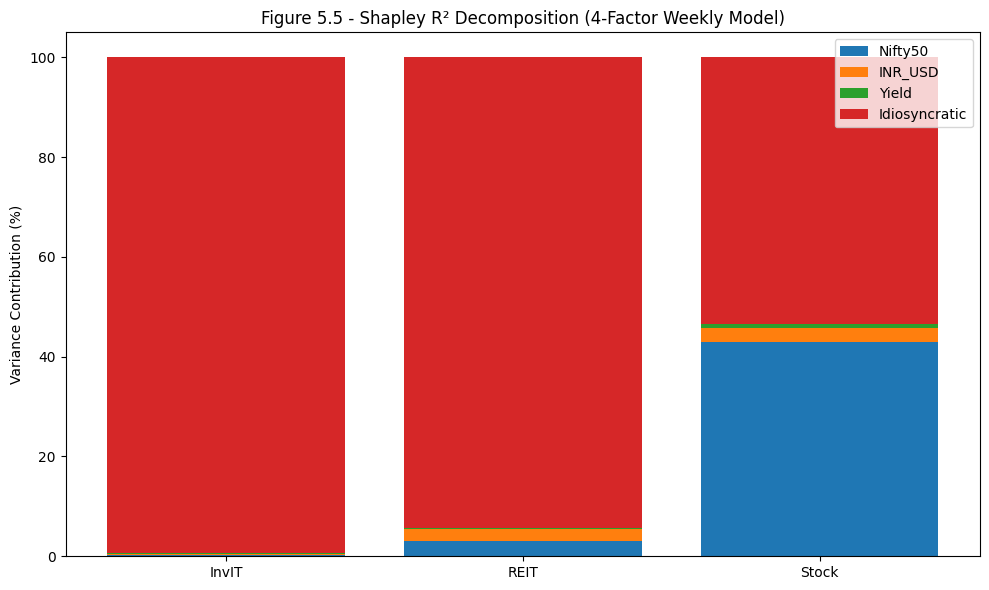

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['InvIT', 'REIT', 'Stock']

# Values in percentage points of total variance (R²)
data = {
    'Nifty50': [0.3, 3.08, 42.89],
    'INR_USD': [0.1, 2.31, 2.8],
    'Yield':   [0.2, 0.3, 0.8],
    'Idiosyncratic': [99.4, 94.3, 53.5]
}

bottom = np.zeros(len(categories))

plt.figure(figsize=(10,6))

for key in data:
    plt.bar(categories, data[key], bottom=bottom, label=key)
    bottom += np.array(data[key])

plt.ylabel('Variance Contribution (%)')
plt.title('Figure 5.5 - Shapley R² Decomposition (4-Factor Weekly Model)')
plt.legend()

plt.tight_layout()
plt.show()

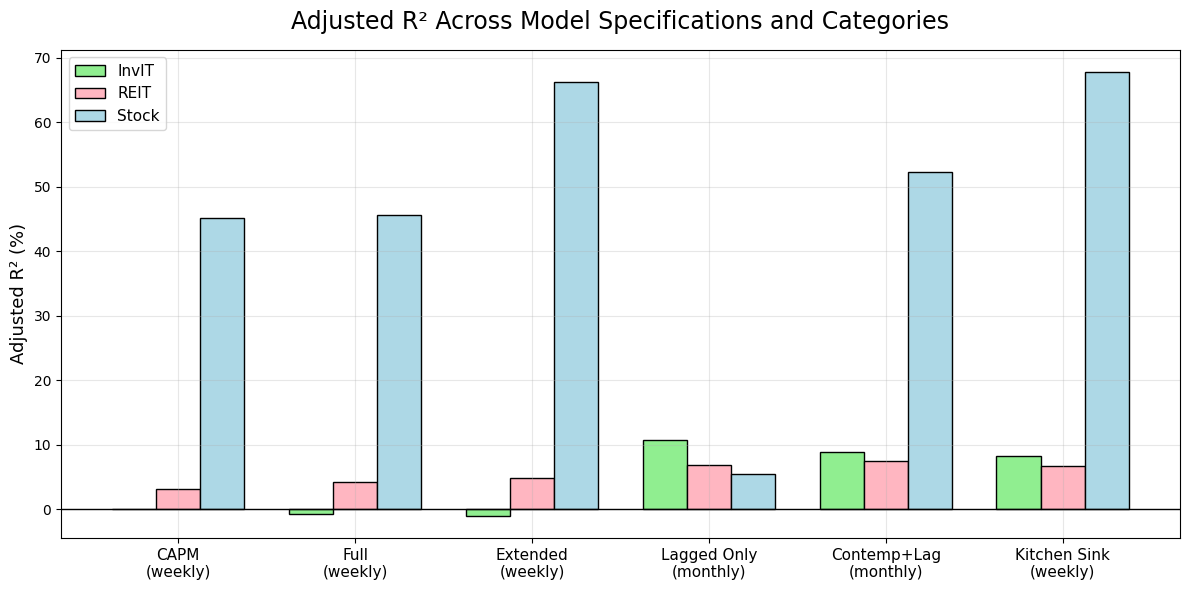

In [40]:
# ============================================================
# FIGURE 5.4 — Adjusted R² Across Specifications and Categories
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

models = [
    'CAPM\n(weekly)',
    'Full\n(weekly)',
    'Extended\n(weekly)',
    'Lagged Only\n(monthly)',
    'Contemp+Lag\n(monthly)',
    'Kitchen Sink\n(weekly)'
]

invit = [0.0, -0.8, -1.0, 10.8, 8.8, 8.2]
reit = [3.2, 4.2, 4.9, 6.8, 7.5, 6.7]
stock = [45.2, 45.7, 66.2, 5.5, 52.3, 67.8]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))

ax.bar(x - width, invit, width,
       label='InvIT',
       edgecolor='black',
       color='lightgreen')

ax.bar(x, reit, width,
       label='REIT',
       edgecolor='black',
       color='lightpink')

ax.bar(x + width, stock, width,
       label='Stock',
       edgecolor='black',
       color='lightblue')

ax.axhline(0, color='black', linewidth=1)

ax.set_ylabel('Adjusted R² (%)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)

ax.set_title(
    'Adjusted R² Across Model Specifications and Categories',
    fontsize=17,
    pad=15
)

ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

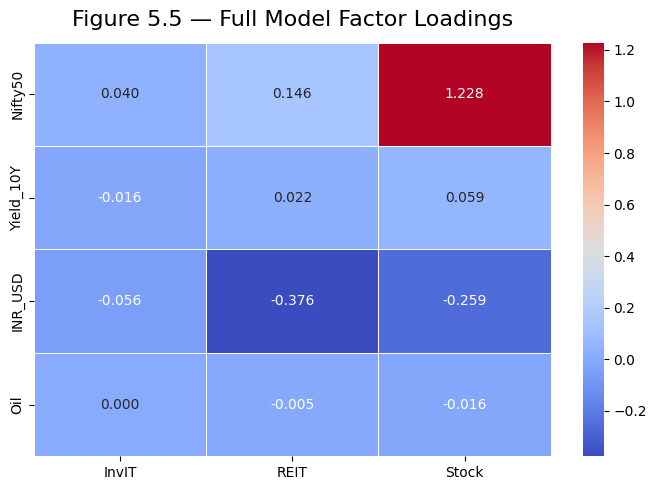

In [41]:
# ============================================================
# SIMPLIFIED FACTOR LOADING HEATMAP (PPT FRIENDLY)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

factor_data = pd.DataFrame({
    'InvIT': [0.040, -0.016, -0.056, 0.000],
    'REIT': [0.146, 0.022, -0.376, -0.005],
    'Stock': [1.228, 0.059, -0.259, -0.016]
},
index=['Nifty50', 'Yield_10Y', 'INR_USD', 'Oil'])

plt.figure(figsize=(7,5))

sns.heatmap(
    factor_data,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title(
    'Figure 5.5 — Full Model Factor Loadings',
    fontsize=16,
    pad=12
)

plt.tight_layout()
plt.show()

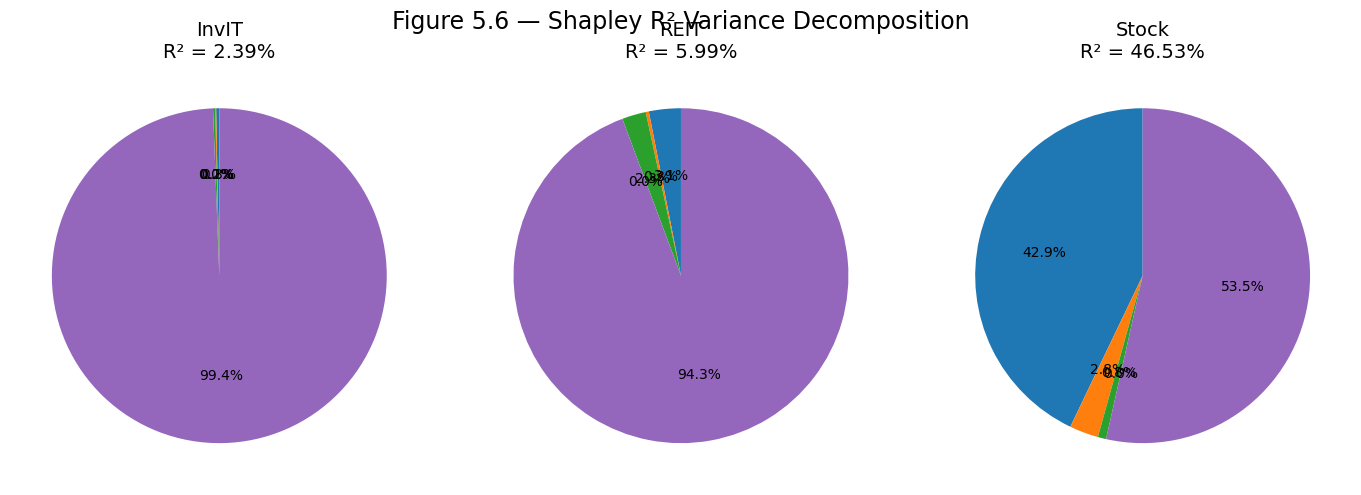

In [42]:
# ============================================================
# FIGURE 5.5 — Shapley R² Variance Decomposition
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14,5))

# ------------------------------------------------
# InvIT
# ------------------------------------------------
labels = ['Nifty50', 'Yield', 'FX', 'Oil', 'Unexplained']
sizes = [0.3, 0.1, 0.2, 0.0, 99.4]

axes[0].pie(
    sizes,
    autopct='%1.1f%%',
    startangle=90
)

axes[0].set_title('InvIT\nR² = 2.39%', fontsize=14)

# ------------------------------------------------
# REIT
# ------------------------------------------------
sizes = [3.08, 0.30, 2.31, 0.0, 94.3]

axes[1].pie(
    sizes,
    autopct='%1.1f%%',
    startangle=90
)

axes[1].set_title('REIT\nR² = 5.99%', fontsize=14)

# ------------------------------------------------
# Stock
# ------------------------------------------------
sizes = [42.89, 2.80, 0.80, 0.0, 53.5]

axes[2].pie(
    sizes,
    autopct='%1.1f%%',
    startangle=90
)

axes[2].set_title('Stock\nR² = 46.53%', fontsize=14)

fig.suptitle(
    'Figure 5.6 — Shapley R² Variance Decomposition',
    fontsize=17
)

plt.tight_layout()
plt.show()

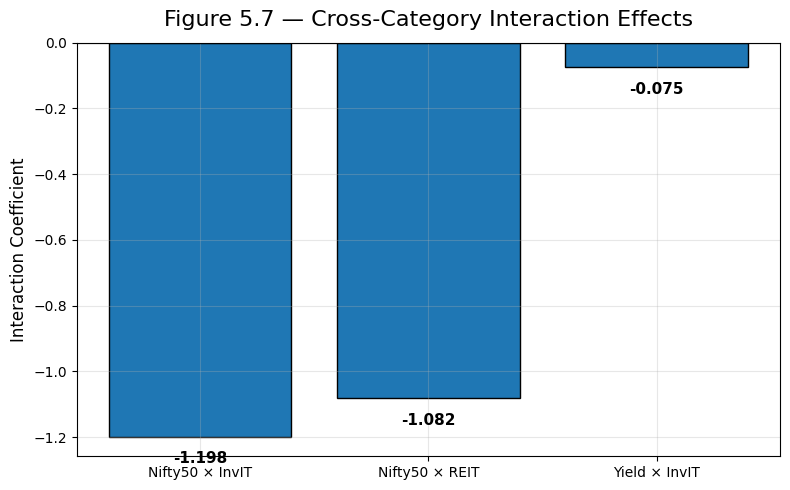

In [43]:
# ============================================================
# CROSS-CATEGORY INTERACTION EFFECTS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

terms = [
    'Nifty50 × InvIT',
    'Nifty50 × REIT',
    'Yield × InvIT'
]

coeffs = [-1.198, -1.082, -0.075]

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    terms,
    coeffs,
    edgecolor='black'
)

ax.axhline(0, color='black')

for i, val in enumerate(coeffs):
    ax.text(
        i,
        val - 0.08,
        f'{val:.3f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

ax.set_ylabel('Interaction Coefficient', fontsize=12)

ax.set_title(
    'Figure 5.7 — Cross-Category Interaction Effects',
    fontsize=16,
    pad=12
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

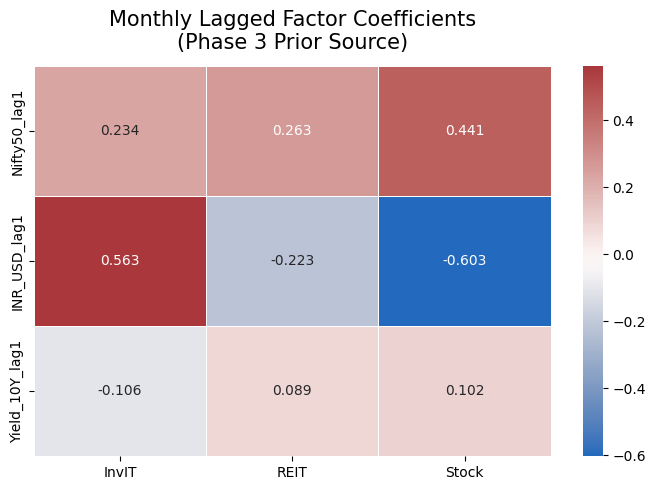

In [45]:
# ============================================================
# PHASE 3 PRIOR SOURCE — MONTHLY LAGGED FACTORS
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

prior_df = pd.DataFrame({
    'InvIT': [0.2338, 0.5629, -0.1057],
    'REIT': [0.2629, -0.2228, 0.0889],
    'Stock': [0.4414, -0.6031, 0.1023]
},
index=['Nifty50_lag1', 'INR_USD_lag1', 'Yield_10Y_lag1'])

plt.figure(figsize=(7,5))

sns.heatmap(
    prior_df,
    annot=True,
    fmt='.3f',
    cmap='vlag',
    linewidths=0.5
)

plt.title(
    'Monthly Lagged Factor Coefficients\n(Phase 3 Prior Source)',
    fontsize=15,
    pad=12
)

plt.tight_layout()
plt.show()